
# <div style="text-align:center; color:Blue; font-weight:bold;">Introducción al Proyecto de aula</div>


La base de datos seleccionada fue **[Car Price](https://www.kaggle.com/datasets/yaaryiitturan/auto-scout-car-price)**
disponible en la plataforma Kaggle. Este dataset recopila información de vehículos nuevos y usados ofertados en la compañía AutoScout24 durante el año 2019. Incluye variables técnicas y comerciales relevantes como la marca, modelo, años de uso, kilometraje, tipo de combustible, potencia del motor, transmisión, entre otras.

Mediante las variables disponibles en la base datos, es posible realizar un análisis de cuáles de estas características se asocian de manera más significativa con el precio final de los autos, permitiendo responder a la pregunta de investigación planteada y aportar evidencia sobre los factores que más influyen en la valoración del mercado automotriz.

<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;">
<b>Pregunta de investigación</b>  
</div>
¿Cuáles son las principales variables que influyen en el precio de los autos publicados en la plataforma AutoScout24 durante el año 2019?
<br> 


<div style="background-color:#E3F2FD; border-left:6px solid #43A047; padding:10px 15px; border-radius:6px; margin-bottom:15px;">
<b>Tabla descriptiva de las variables</b><br>
</div>

<p style="text-align:center;">
  <img src="imgs/tabla.jpg" alt="bannersp" style="width:60%; border-radius:10px;">
</p>


### **Fuente de los datos**
- Dataset: **Auto Scout Car Price**
  **Repositorio:** [UCI Machine Learning Repository](https://www.kaggle.com/datasets/yaaryiitturan/auto-scout-car-price).  
  **Autores:** Yaaryiitturan Kaggle  
  **Descripción:** Este conjunto de datos proporciona información completa sobre anuncios de autos usados, incluyendo especificaciones, características, precios y más. Resulta valioso para analizar precios, tendencias y preferencias de los clientes en el mercado automotriz. Los datos se recopilaron en 2019 de la empresa de comercio de automóviles en línea AutoScout24 y contienen muchas características de 9 modelos de automóviles diferentes.

<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;">
<b> Carga de los datos</b>  
</div>

In [45]:
# Uso de Librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import skew, kurtosis
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
from numpy.linalg import svd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
from IPython.display import display, HTML
display(HTML("<style>.output_scroll {height:auto !important; max-height:none !important;}</style>"))



In [2]:
# Estilo general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Crear dataset
df = pd.read_csv("../datos/dataset_depurado.csv", sep=";")

<Figure size 1200x600 with 0 Axes>

In [3]:
# Visualizar una pequeña muestra de los datos
df.head()

,price,km,Fuel,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb
0,15770,56013.0,Diesel,7,3,2,66,1,1422,1220,3.8
1,14500,80000.0,Benzine,7,2,1,141,0,1798,1255,5.6
2,14640,83450.0,Diesel,7,3,1,85,0,1598,1135,3.8
3,14500,73000.0,Diesel,6,3,1,66,0,1422,1195,3.8
4,16790,16200.0,Diesel,7,3,1,66,1,1422,1135,4.1


In [4]:
# Número de registros y variables
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 15915
Número de variables: 11


In [5]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())


Tipos de datos por variable:
int64      8
float64    2
object     1
Name: count, dtype: int64


In [6]:
# Clasificación de variables
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🔹 Variables categóricas:")
print("\n".join([f"- {col}" for col in categoricas]))

print("\n🔸 Variables numéricas:")
print("\n".join([f"- {col}" for col in numericas]))

🔹 Variables categóricas:
- Fuel

🔸 Variables numéricas:
- price
- km
- Gears
- age
- Previous_Owners
- hp_kW
- Inspection_new
- Displacement_cc
- Weight_kg
- cons_comb


En la selección de variables se optó por seleccionar una variable categórica y transformarla en discreta con la siguiente relación:
1. Benzine (gasolina)
2. Diesel
3. Electric
4. Gas

Esto debido a la importancia de la elección del precio de un auto, por este tipo de característica.

In [7]:
# Descripción general
print("\nDescripción de variables numéricas:")
print(df.describe())


Descripción de variables numéricas:
              price             km         Gears           age  \
count  15915.000000   15915.000000  15915.000000  15915.000000   
mean   18024.380584   32089.995708      5.937355      1.389695   
std     7381.679318   36977.214964      0.704772      1.121306   
min     4950.000000       0.000000      5.000000      0.000000   
25%    12850.000000    1920.500000      5.000000      0.000000   
50%    16900.000000   20413.000000      6.000000      1.000000   
75%    21900.000000   46900.000000      6.000000      2.000000   
max    74600.000000  317000.000000      8.000000      3.000000   

       Previous_Owners         hp_kW  Inspection_new  Displacement_cc  \
count     15915.000000  15915.000000    15915.000000     15915.000000   
mean          1.042853     88.499340        0.247063      1428.661891   
std           0.339178     26.674341        0.431317       275.804272   
min           0.000000     40.000000        0.000000       890.000000   
25%

In [8]:
# Conteo de valores faltantes ordenado de mayor a menor
faltantes = df.isnull().sum().sort_values(ascending=False)

print("\nConteo de valores faltantes por variable:")
print(faltantes[faltantes > 0])  # Solo muestra variables con al menos un valor faltante


Conteo de valores faltantes por variable:
Series([], dtype: int64)


In [9]:
# Conteo de valores únicos por variable
print("\nConteo de valores únicos por variable:")
print(df.nunique().sort_values(ascending=False))


Conteo de valores únicos por variable:
km                 6691
price              2952
Weight_kg           432
hp_kW                77
Displacement_cc      68
cons_comb            61
Previous_Owners       5
Fuel                  4
age                   4
Gears                 4
Inspection_new        2
dtype: int64


## <span style="color:black;"><strong>Análisis Univariado</strong></span>

### <span style="color:black;"><strong>Variables continuas</strong></span>

#### <span style="color:black;"><strong>Precio</strong></span>


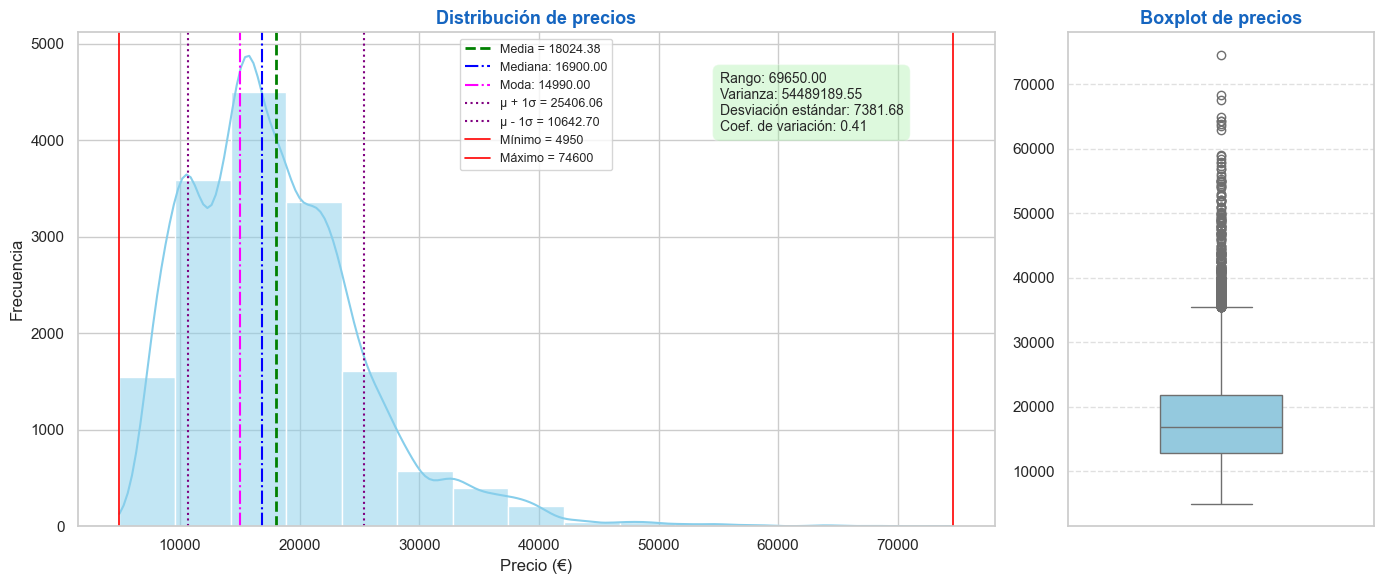

In [17]:
# Cálculo de medidas descriptivas
media = np.mean(df['price'])
mediana = np.median(df['price'])
moda = stats.mode(df['price'], keepdims=True).mode[0]
minimo = np.min(df['price'])
maximo = np.max(df['price'])
rango = maximo - minimo
varianza = np.var(df['price'], ddof=1)
desviacion = np.std(df['price'], ddof=1)
coef_var = desviacion / media


# Visualización 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(wspace=0.3)

# HISTOGRAMA
sns.histplot(df['price'], bins=15, kde=True, color='skyblue', ax=axes[0])

# Líneas verticales de referencia
axes[0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='blue', linestyle='-.', label=f'Mediana: {mediana:.2f}')
axes[0].axvline(moda, color='magenta', linestyle='-.', label=f'Moda: {moda:.2f}')
axes[0].axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ + 1σ = {media + desviacion:.2f}')
axes[0].axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ - 1σ = {media - desviacion:.2f}')
axes[0].axvline(minimo, color='red', linestyle='-', linewidth=1.2, label=f'Mínimo = {minimo:.0f}')
axes[0].axvline(maximo, color='red', linestyle='-', linewidth=1.2, label=f'Máximo = {maximo:.0f}')

# Título y etiquetas
axes[0].set_title("Distribución de precios", fontsize=13, weight='bold', color='#1565C0')
axes[0].set_xlabel("Precio (€)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

# Recuadro con medidas estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
axes[0].text(
    0.7, 0.8, texto, transform=axes[0].transAxes,
    bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle="round,pad=0.5"),
    fontsize=10
)

# BOXPLOT 
sns.boxplot(y=df['price'], color='skyblue', width=0.4, ax=axes[1])
axes[1].set_title("Boxplot de precios", fontsize=13, weight='bold', color='#1565C0')
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()


### <span style="color:red;"><strong>Interpretación</strong></span>
 
 price (precio del auto)
 
- Media = 18024 y Mediana = 16900; la media es mayor que la mediana lo que determina que la distribución esta sesgada a la derecha.
- La moda es más baja, con un valor de 14990 euros lo que muestra que hay cierta concentración de precios menores al promedio.
- Rango muy grande (4,950 a 74,600): presenta alta variabilidad.
- CV = 41%: presenta una variación considerada moderada alta.
- En el histograma, se observa una concentración importante de precios entre los 10000 y 30000 euros.


#### <span style="color:black;"><strong>Kilometraje</strong></span>


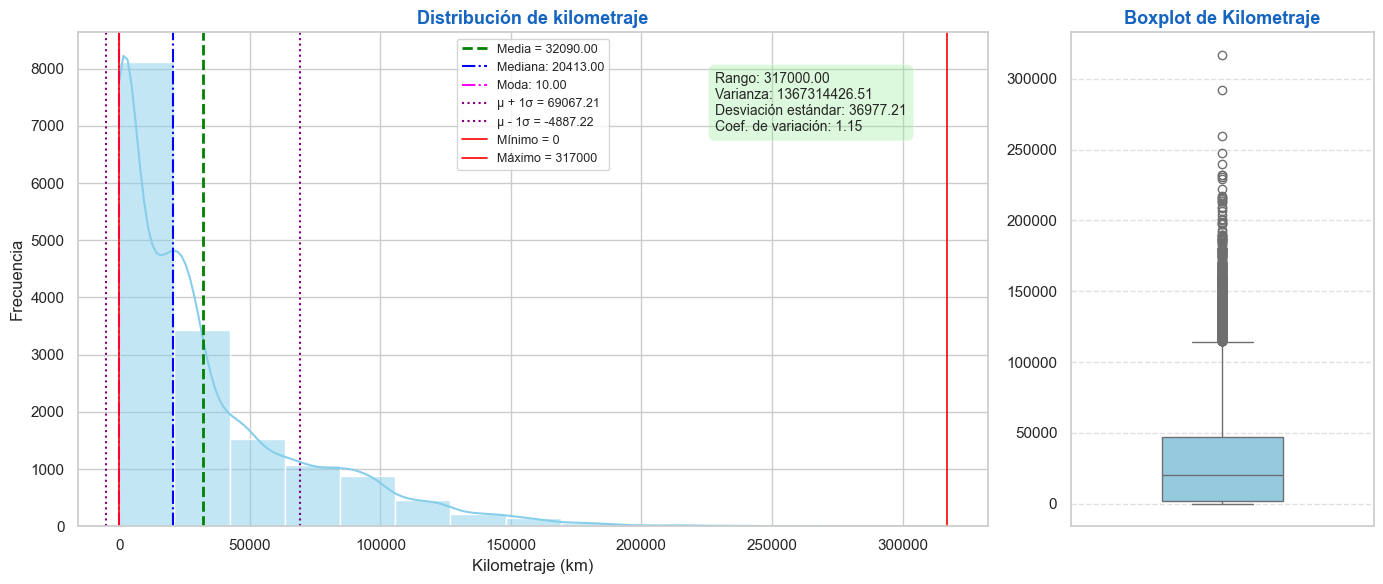

In [19]:
# Cálculo de medidas descriptivas
media = np.mean(df['km'])
mediana = np.median(df['km'])
moda = stats.mode(df['km'], keepdims=True).mode[0]
minimo = np.min(df['km'])
maximo = np.max(df['km'])
rango = maximo - minimo
varianza = np.var(df['km'], ddof=1)
desviacion = np.std(df['km'], ddof=1)
coef_var = desviacion / media


# Visualización 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(wspace=0.3)

# Histograma
sns.histplot(df['km'], bins=15, kde=True, color='skyblue', ax=axes[0])

# Líneas verticales de referencia
axes[0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='blue', linestyle='-.', label=f'Mediana: {mediana:.2f}')
axes[0].axvline(moda, color='magenta', linestyle='-.', label=f'Moda: {moda:.2f}')
axes[0].axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ + 1σ = {media + desviacion:.2f}')
axes[0].axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ - 1σ = {media - desviacion:.2f}')
axes[0].axvline(minimo, color='red', linestyle='-', linewidth=1.2, label=f'Mínimo = {minimo:.0f}')
axes[0].axvline(maximo, color='red', linestyle='-', linewidth=1.2, label=f'Máximo = {maximo:.0f}')

# Título y etiquetas
axes[0].set_title("Distribución de kilometraje", fontsize=13, weight='bold', color='#1565C0')
axes[0].set_xlabel("Kilometraje (km)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

# Recuadro con medidas estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
axes[0].text(
    0.7, 0.8, texto, transform=axes[0].transAxes,
    bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle="round,pad=0.5"),
    fontsize=10
)

# Boxplot
sns.boxplot(y=df['km'], color='skyblue', width=0.4, ax=axes[1])
axes[1].set_title("Boxplot de Kilometraje", fontsize=13, weight='bold', color='#1565C0')
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

### <span style="color:red;"><strong>Interpretación</strong></span>
 
 km (kilometraje del auto)
 
- Media = 32090 y Mediana = 20413; la media es mayor que la mediana lo que determina que la distribución esta fuertemente sesgada a la derecha.
- La moda es mucho más baja, con un valor de 10 kilómetros lo que muestra que hay cierta concentración de precios menores al promedio.
- Rango muy grande (0 a 317,000): presenta muy alta variabilidad.
- CV = 115%: presenta una variación considerada alta lo que hace que sea una variable muy dispersa y poco homogénea.
- En el histograma, se observa una concentración importante de km entre los 0 y 50000 km.


#### <span style="color:black;"><strong>Potencia</strong></span>

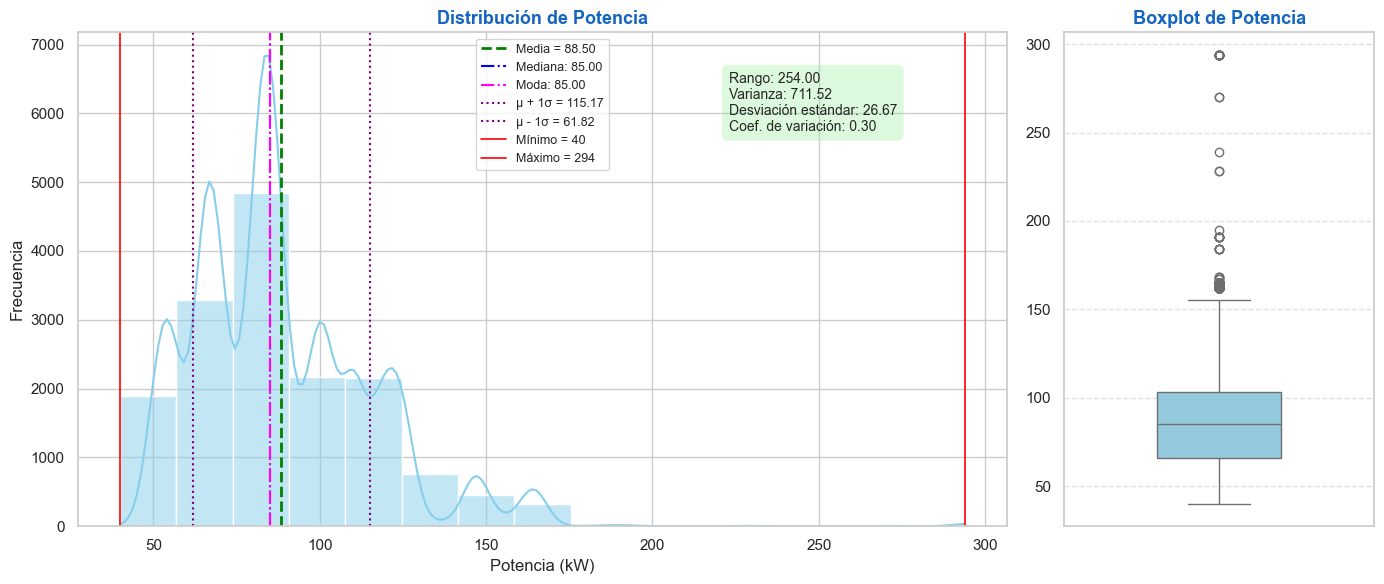

In [21]:
# Cálculo de medidas descriptivas
media = np.mean(df['hp_kW'])
mediana = np.median(df['hp_kW'])
moda = stats.mode(df['hp_kW'], keepdims=True).mode[0]
minimo = np.min(df['hp_kW'])
maximo = np.max(df['hp_kW'])
rango = maximo - minimo
varianza = np.var(df['hp_kW'], ddof=1)
desviacion = np.std(df['hp_kW'], ddof=1)
coef_var = desviacion / media


# Visualización 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(wspace=0.3)

# Histograma
sns.histplot(df['hp_kW'], bins=15, kde=True, color='skyblue', ax=axes[0])

# Líneas verticales de referencia
axes[0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='blue', linestyle='-.', label=f'Mediana: {mediana:.2f}')
axes[0].axvline(moda, color='magenta', linestyle='-.', label=f'Moda: {moda:.2f}')
axes[0].axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ + 1σ = {media + desviacion:.2f}')
axes[0].axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ - 1σ = {media - desviacion:.2f}')
axes[0].axvline(minimo, color='red', linestyle='-', linewidth=1.2, label=f'Mínimo = {minimo:.0f}')
axes[0].axvline(maximo, color='red', linestyle='-', linewidth=1.2, label=f'Máximo = {maximo:.0f}')

# Título y etiquetas
axes[0].set_title("Distribución de Potencia", fontsize=13, weight='bold', color='#1565C0')
axes[0].set_xlabel("Potencia (kW)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

# Recuadro con medidas estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
axes[0].text(
    0.7, 0.8, texto, transform=axes[0].transAxes,
    bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle="round,pad=0.5"),
    fontsize=10
)

# Boxplot
sns.boxplot(y=df['hp_kW'], color='skyblue', width=0.4, ax=axes[1])
axes[1].set_title("Boxplot de Potencia", fontsize=13, weight='bold', color='#1565C0')
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

### <span style="color:red;"><strong>Interpretación</strong></span>
 
 hp_kW (Potencia del auto medida en kW)
 
- Media = 88.5 y Mediana = 85; la variable esta bastante centrada por la cercanía entre estas dos medidas, además la moda 85, pero igual esta sesgada a la derecha
- Rango de (40 a 294): presenta baja variabilidad.
- CV = 30%: presenta una variabilidad moderada. 
- En el histograma, se observa una concentración importante de hp_kW entre los 60 y 120.


#### <span style="color:black;"><strong>Tamaño del motor</strong></span>

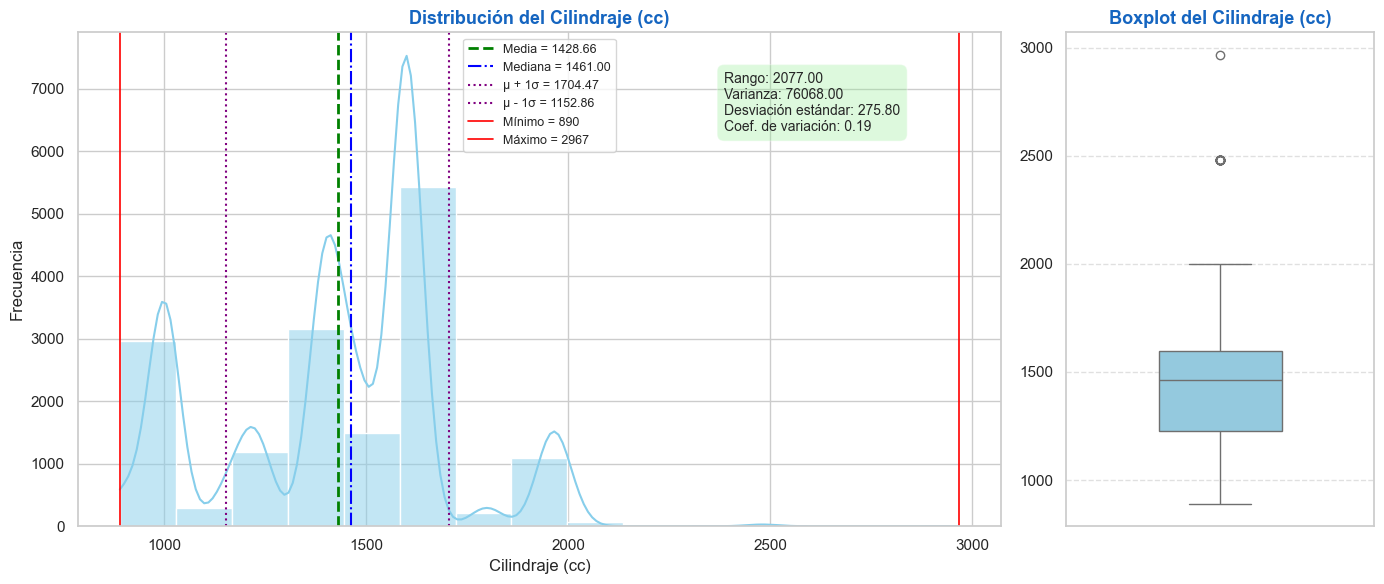

In [22]:
# Cálculo de medidas descriptivas
media = np.mean(df['Displacement_cc'])
mediana = np.median(df['Displacement_cc'])
minimo = np.min(df['Displacement_cc'])
maximo = np.max(df['Displacement_cc'])
rango = maximo - minimo
varianza = np.var(df['Displacement_cc'], ddof=1)
desviacion = np.std(df['Displacement_cc'], ddof=1)
coef_var = desviacion / media

# Visualización 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(wspace=0.3)

# HISTOGRAMA
sns.histplot(df['Displacement_cc'], bins=15, kde=True, color='skyblue', ax=axes[0])

# Líneas verticales
axes[0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='blue', linestyle='-.', label=f'Mediana = {mediana:.2f}')
axes[0].axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ + 1σ = {media + desviacion:.2f}')
axes[0].axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ - 1σ = {media - desviacion:.2f}')
axes[0].axvline(minimo, color='red', linestyle='-', linewidth=1.2, label=f'Mínimo = {minimo:.0f}')
axes[0].axvline(maximo, color='red', linestyle='-', linewidth=1.2, label=f'Máximo = {maximo:.0f}')

# Título y etiquetas
axes[0].set_title("Distribución del Cilindraje (cc)", fontsize=13, weight='bold', color='#1565C0')
axes[0].set_xlabel("Cilindraje (cc)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

# Recuadro con medidas estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
axes[0].text(0.7, 0.8, texto, transform=axes[0].transAxes,
             bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle='round,pad=0.5'), fontsize=10)

# BOXPLOT
sns.boxplot(y=df['Displacement_cc'], color='skyblue', width=0.4, ax=axes[1])
axes[1].set_title("Boxplot del Cilindraje (cc)", fontsize=13, weight='bold', color='#1565C0')
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


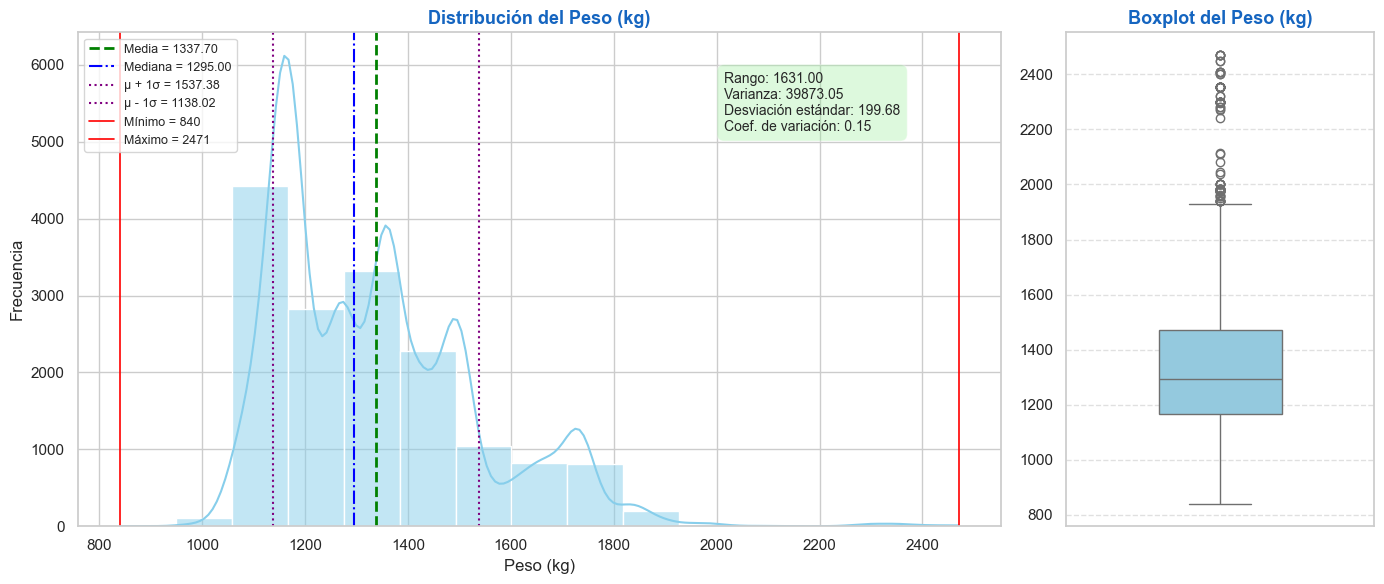

In [23]:
# Cálculo de medidas descriptivas
media = np.mean(df['Weight_kg'])
mediana = np.median(df['Weight_kg'])
minimo = np.min(df['Weight_kg'])
maximo = np.max(df['Weight_kg'])
rango = maximo - minimo
varianza = np.var(df['Weight_kg'], ddof=1)
desviacion = np.std(df['Weight_kg'], ddof=1)
coef_var = desviacion / media

# Visualización 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(wspace=0.3)

# HISTOGRAMA
sns.histplot(df['Weight_kg'], bins=15, kde=True, color='skyblue', ax=axes[0])

# Líneas verticales
axes[0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='blue', linestyle='-.', label=f'Mediana = {mediana:.2f}')
axes[0].axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ + 1σ = {media + desviacion:.2f}')
axes[0].axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ - 1σ = {media - desviacion:.2f}')
axes[0].axvline(minimo, color='red', linestyle='-', linewidth=1.2, label=f'Mínimo = {minimo:.0f}')
axes[0].axvline(maximo, color='red', linestyle='-', linewidth=1.2, label=f'Máximo = {maximo:.0f}')

# Título y etiquetas
axes[0].set_title("Distribución del Peso (kg)", fontsize=13, weight='bold', color='#1565C0')
axes[0].set_xlabel("Peso (kg)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

# Recuadro con medidas estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
axes[0].text(0.7, 0.8, texto, transform=axes[0].transAxes,
             bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle='round,pad=0.5'), fontsize=10)

# BOXPLOT
sns.boxplot(y=df['Weight_kg'], color='skyblue', width=0.4, ax=axes[1])
axes[1].set_title("Boxplot del Peso (kg)", fontsize=13, weight='bold', color='#1565C0')
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


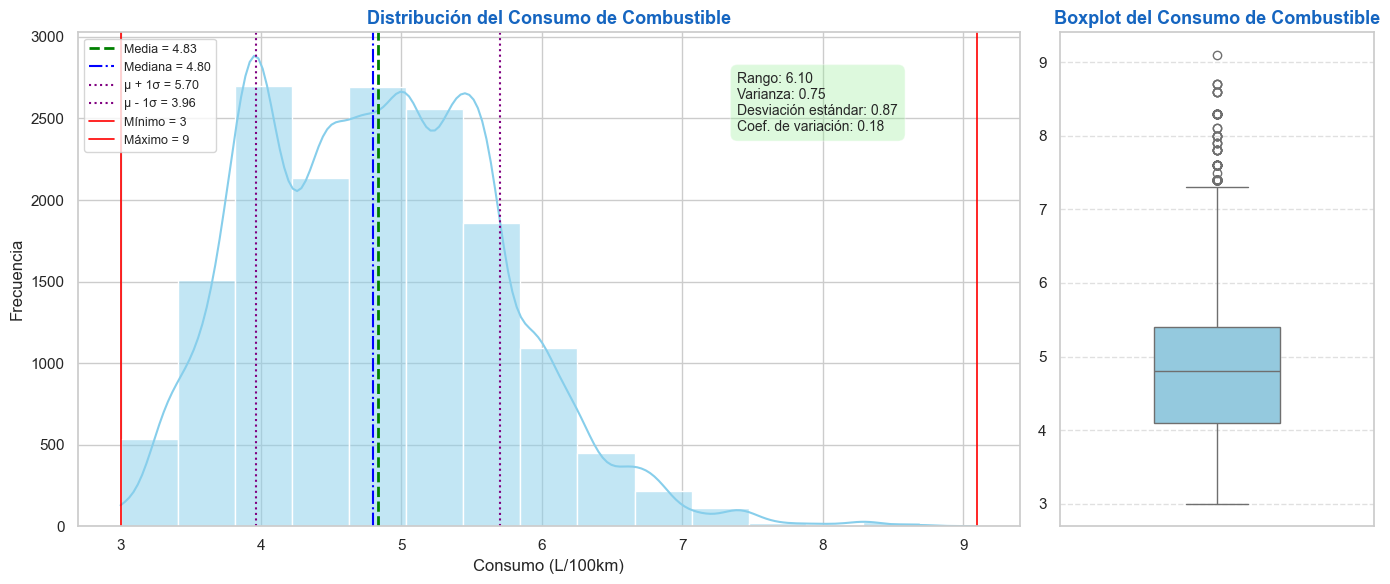

In [24]:
# Cálculo de medidas descriptivas
media = np.mean(df['cons_comb'])
mediana = np.median(df['cons_comb'])
minimo = np.min(df['cons_comb'])
maximo = np.max(df['cons_comb'])
rango = maximo - minimo
varianza = np.var(df['cons_comb'], ddof=1)
desviacion = np.std(df['cons_comb'], ddof=1)
coef_var = desviacion / media

# Visualización 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(wspace=0.3)

# HISTOGRAMA
sns.histplot(df['cons_comb'], bins=15, kde=True, color='skyblue', ax=axes[0])

# Líneas verticales
axes[0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='blue', linestyle='-.', label=f'Mediana = {mediana:.2f}')
axes[0].axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ + 1σ = {media + desviacion:.2f}')
axes[0].axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ - 1σ = {media - desviacion:.2f}')
axes[0].axvline(minimo, color='red', linestyle='-', linewidth=1.2, label=f'Mínimo = {minimo:.0f}')
axes[0].axvline(maximo, color='red', linestyle='-', linewidth=1.2, label=f'Máximo = {maximo:.0f}')

# Título y etiquetas
axes[0].set_title("Distribución del Consumo de Combustible", fontsize=13, weight='bold', color='#1565C0')
axes[0].set_xlabel("Consumo (L/100km)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

# Recuadro con medidas estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
axes[0].text(0.7, 0.8, texto, transform=axes[0].transAxes,
             bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle='round,pad=0.5'), fontsize=10)

# BOXPLOT
sns.boxplot(y=df['cons_comb'], color='skyblue', width=0.4, ax=axes[1])
axes[1].set_title("Boxplot del Consumo de Combustible", fontsize=13, weight='bold', color='#1565C0')
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


#### <span style="color:black;"><strong>Análisis de Distribución</strong></span>

### <span style="color:#2F749F;"><strong>Cálculo de medidas de distribución</strong></span>

1. Asimetría
2. Curtosis


In [27]:

variables_continuas = ['price', 'km','hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb' ]

resultados = []

for var in variables_continuas:
    datos = df[var].dropna()
    asimetria = skew(datos)
    curtosis_valor = kurtosis(datos, fisher=True)
    resultados.append({
        'Variable': var,
        'Asimetría (Skew)': round(asimetria, 3),
        'Curtosis (Kurtosis)': round(curtosis_valor, 3)
        
    })

tabla_asim_curt = pd.DataFrame(resultados)
print(tabla_asim_curt)


          Variable  Asimetría (Skew)  Curtosis (Kurtosis)
0            price             1.236                2.964
1               km             1.623                2.824
2            hp_kW             1.292                4.385
3  Displacement_cc            -0.097               -0.202
4        Weight_kg             1.082                1.594
5        cons_comb             0.419                0.115


### interpretación

precio:
- La Asimetría 1.23 (>0): presenta sesgo a la derecha.
- 
- Curtosis 5.96 (>3) → distribución con colas pesadas (valores extremos).

### Percentiles, Deciles y cuartiles

### <span style="color:#2F749F;"><strong>Cálculo de medidas de percentiles</strong></span>

1. Percentiles
2. Deciles
3. Cuartiles
4. Grafica los anteriores percentiles calculados, sobre la distribución de tus datos 



C:\Users\Nitro V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


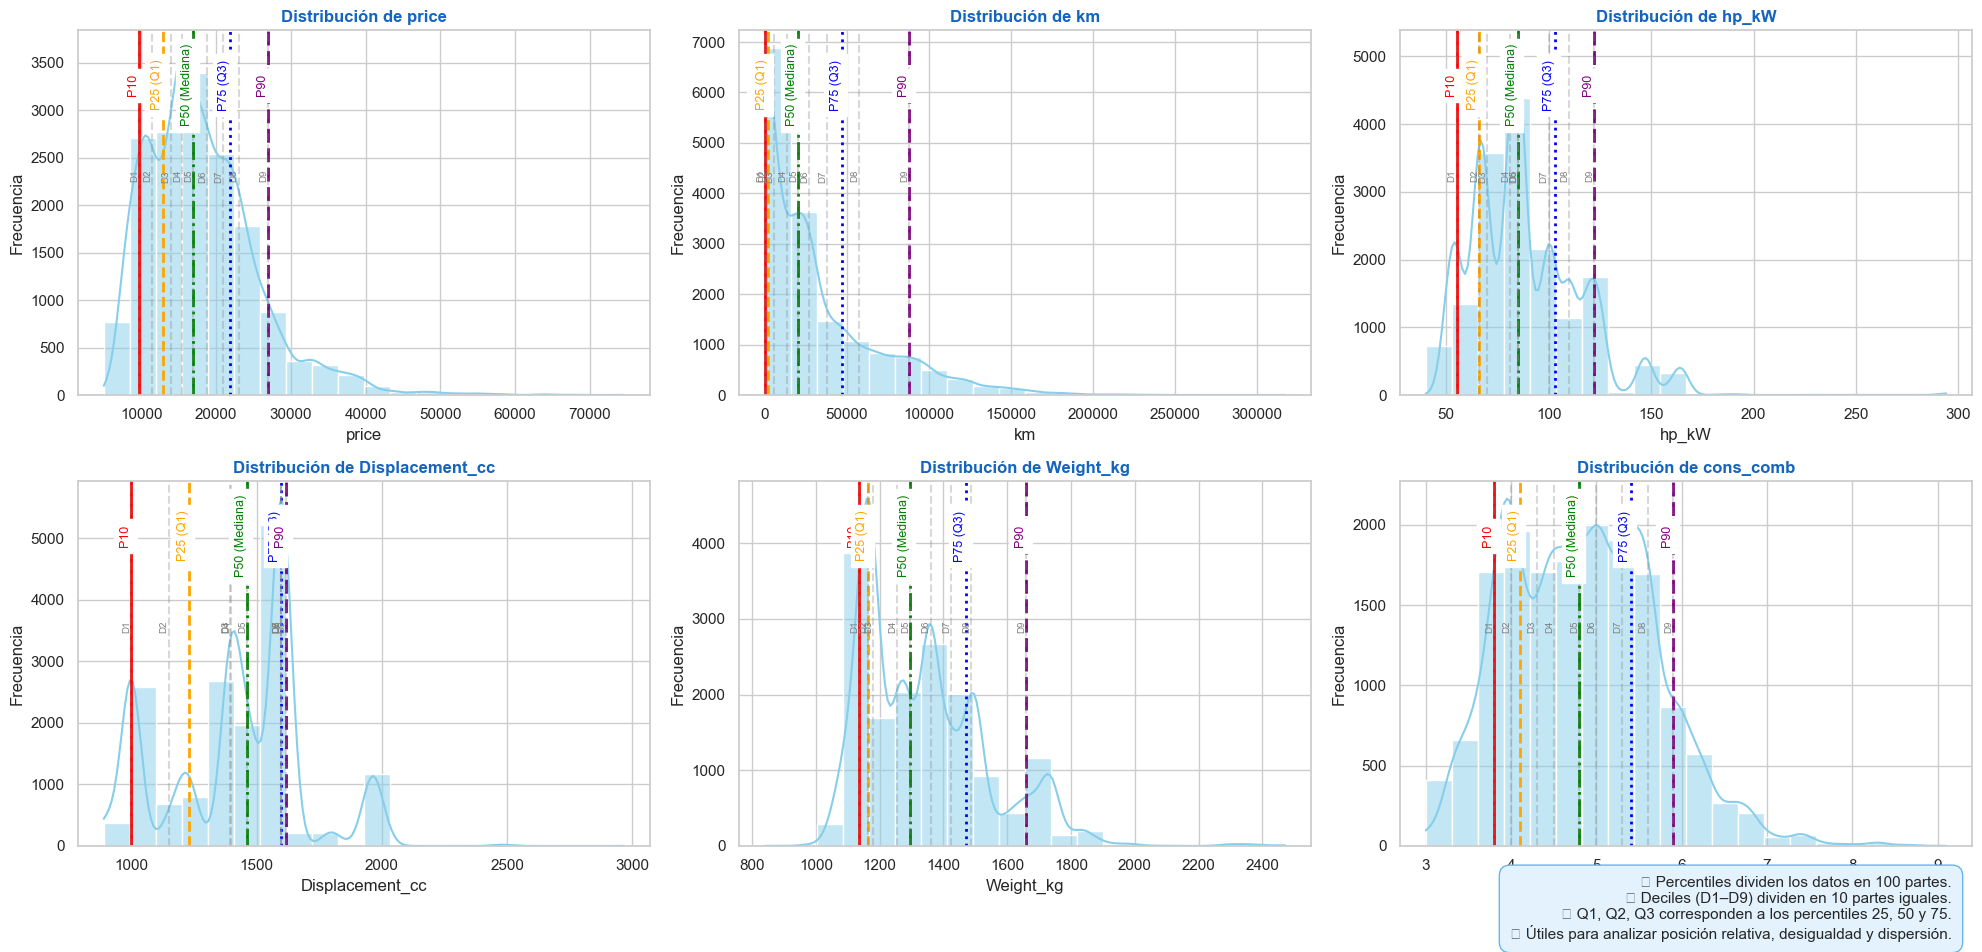

In [29]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, var in enumerate(variables_continuas):
    datos = df[var].dropna()
    
    # Percentiles clave
    percentiles = {
        'P10': {'valor': np.percentile(datos, 10), 'color': 'red', 'linestyle': '-'},
        'P25 (Q1)': {'valor': np.percentile(datos, 25), 'color': 'orange', 'linestyle': '--'},
        'P50 (Mediana)': {'valor': np.percentile(datos, 50), 'color': 'green', 'linestyle': '-.'},
        'P75 (Q3)': {'valor': np.percentile(datos, 75), 'color': 'blue', 'linestyle': ':'},
        'P90': {'valor': np.percentile(datos, 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
    }

    # Deciles D1–D9
    deciles = {f'D{i}': np.percentile(datos, i * 10) for i in range(1, 10)}

    # Histograma con KDE
    sns.histplot(datos, kde=True, color='skyblue', bins=20, ax=axes[i])
    
    # Líneas para percentiles destacados
    for etiqueta, props in percentiles.items():
        axes[i].axvline(props['valor'], color=props['color'], linestyle=props['linestyle'], linewidth=2)
        axes[i].text(props['valor'], axes[i].get_ylim()[1]*0.85, etiqueta,
                     rotation=90, color=props['color'], fontsize=9,
                     verticalalignment='center', horizontalalignment='right',
                     backgroundcolor='white')
    
    # Líneas más sutiles para deciles
    for etiqueta, valor in deciles.items():
        axes[i].axvline(valor, color='gray', linestyle='--', alpha=0.3)
        axes[i].text(valor, axes[i].get_ylim()[1]*0.6, etiqueta,
                     rotation=90, color='gray', fontsize=7,
                     verticalalignment='center', horizontalalignment='right')

    # Título del subplot
    axes[i].set_title(f"Distribución de {var}", fontsize=12, fontweight='bold', color='#1565C0')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")

# Recuadro explicativo global
texto = (
    "🔹 Percentiles dividen los datos en 100 partes.\n"
    "🔹 Deciles (D1–D9) dividen en 10 partes iguales.\n"
    "🔹 Q1, Q2, Q3 corresponden a los percentiles 25, 50 y 75.\n"
    "🔹 Útiles para analizar posición relativa, desigualdad y dispersión."
)
fig.text(0.98, 0.05, texto, fontsize=11, verticalalignment='bottom',
         horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.7", 
         facecolor="#E3F2FD", edgecolor="#64B5F6"))

# Ajustes finales
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


### <span style="color:red;"><strong>Interpretación</strong></span>


#### <span style="color:black;"><strong>Percetiles</strong></span>
- P10: El 10% de los precios está en 1 mil pesos o menos.
- P25 (Q1): El 25% de los precios está en 3 mil o menos.
- P50 (Mediana): La mitad de los precios está en 4 mil o menos, y la otra mitad en más de 4.
- P75 (Q3): El 75% de los precios está en 5 mil o menos.
- P90: El 90% de los precios está en 7 mil o menos; solo el 10% restante llega a 8 o 9.

Los datos de precios se concentran mayoritariamente entre 2 y 5, con unos pocos precios bajos (0–1) y algunos más altos (7–9). La distribución es bastante simétrica y no presenta colas extremas.

### Análisis de variables discretas

C:\Users\Nitro V15\AppData\Local\Temp\ipykernel_43384\248020029.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], palette="pastel")
C:\Users\Nitro V15\AppData\Local\Temp\ipykernel_43384\248020029.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], palette="pastel")
C:\Users\Nitro V15\AppData\Local\Temp\ipykernel_43384\248020029.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], palette="pastel")
C:\Users\Nitro V15\AppData\Local\Temp\ipykernel_43384\248020029.py:7: FutureWarning: 

Passing `palette` w

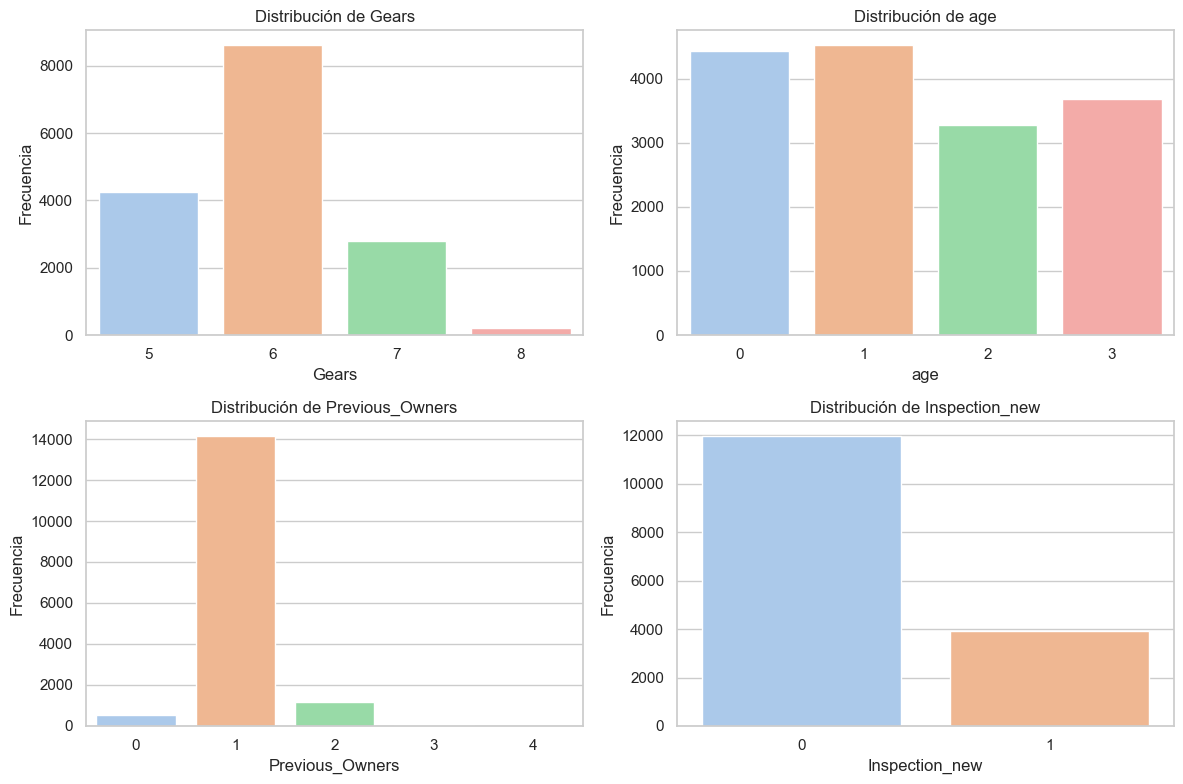

In [40]:
variables_discretas = ['Gears', 'age', 'Previous_Owners', 'Inspection_new']

plt.figure(figsize=(12, 8))

for i, var in enumerate(variables_discretas, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df[var], palette="pastel")
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


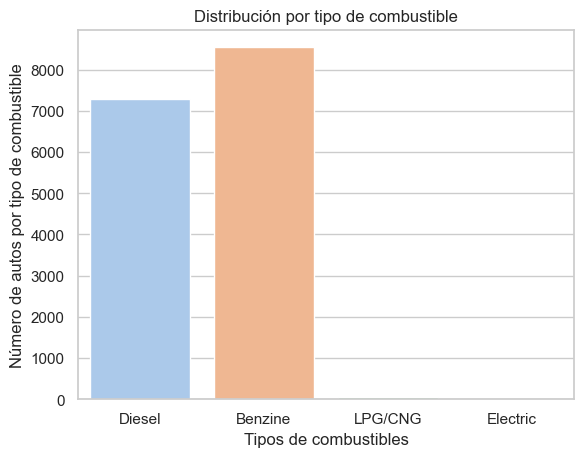

In [33]:
# Gráfico de barras: tipos de combustibles
sns.countplot(x='Fuel', data=df,hue='Fuel', palette='pastel',legend=False)
plt.title("Distribución por tipo de combustible")
plt.xlabel("Tipos de combustibles")
plt.ylabel("Número de autos por tipo de combustible")
plt.show()

## <span style="color:black;"><strong>Análisis Bivariado</strong></span>

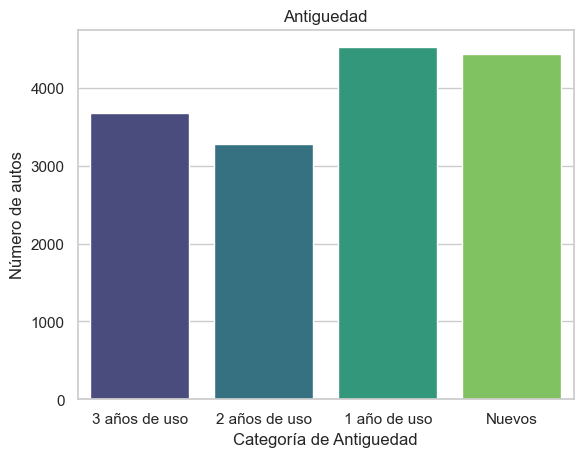

In [12]:
# Gráfico de barras: Antiguedad
# Mapeo de categorías
age_labels = {
    0: "Nuevos",
    1: "1 año de uso",
    2: "2 años de uso",
    3: "3 años de uso"
  }

# Columna con etiquetas
df['age_label'] = df['age'].map(age_labels)

# Gráfico 

sns.countplot(x='age_label',data=df,hue='age_label',palette='viridis',legend=False)
plt.title("Antiguedad")
plt.xlabel("Categoría de Antiguedad")
plt.ylabel("Número de autos")
plt.show()

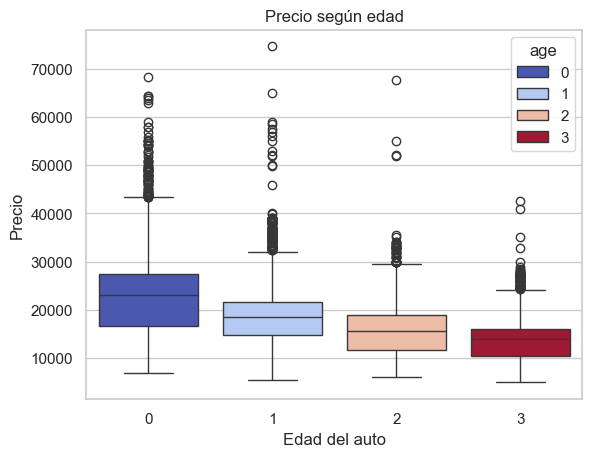

In [35]:
# Gráfico de dispersión: precio vs km
sns.boxplot(x='age', y='price',hue='age', data=df, palette='coolwarm')
plt.title("Precio según edad")
plt.xlabel("Edad del auto")
plt.ylabel("Precio")
plt.show()

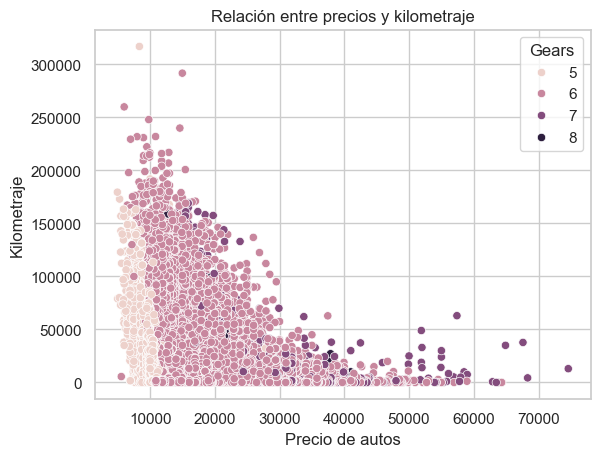

In [36]:
# Gráfico de dispersión: precio vs km
sns.scatterplot(x='price', y='km', hue='Gears', data=df)
plt.title("Relación entre precios y kilometraje")
plt.xlabel("Precio de autos")
plt.ylabel("Kilometraje")
plt.show()

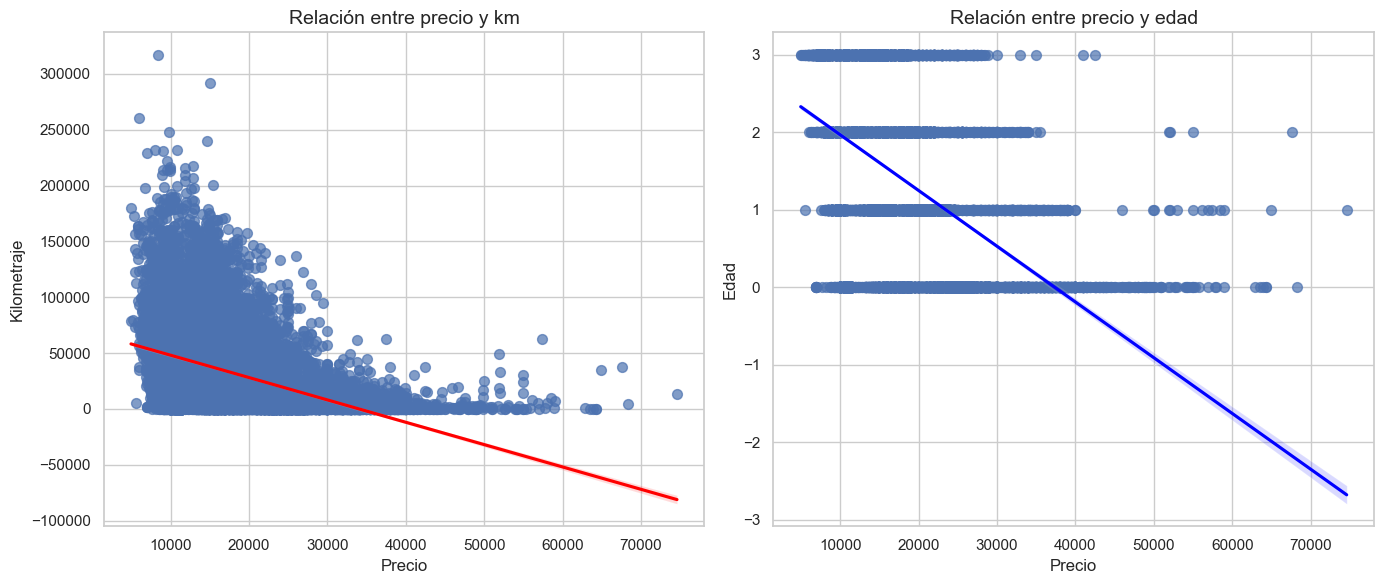

In [37]:
# Gráfico de dispersión con líneas de tendencia
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# precio vs km
sns.regplot(x='price', y='km', data=df, ax=axes[0],
            scatter_kws={'s': 50, 'alpha': 0.7},
            line_kws={'color': 'red'})
axes[0].set_title('Relación entre precio y km', fontsize=14)
axes[0].set_xlabel('Precio', fontsize=12)
axes[0].set_ylabel('Kilometraje', fontsize=12)

# pricio vs edad
sns.regplot(x='price', y='age', data=df, ax=axes[1],
            scatter_kws={'s': 50, 'alpha': 0.7},
            line_kws={'color': 'blue'})
axes[1].set_title('Relación entre precio y edad', fontsize=14)
axes[1].set_xlabel('Precio', fontsize=12)
axes[1].set_ylabel('Edad', fontsize=12)

plt.tight_layout()
plt.show()

### Coeficiente de correlación de Pearson

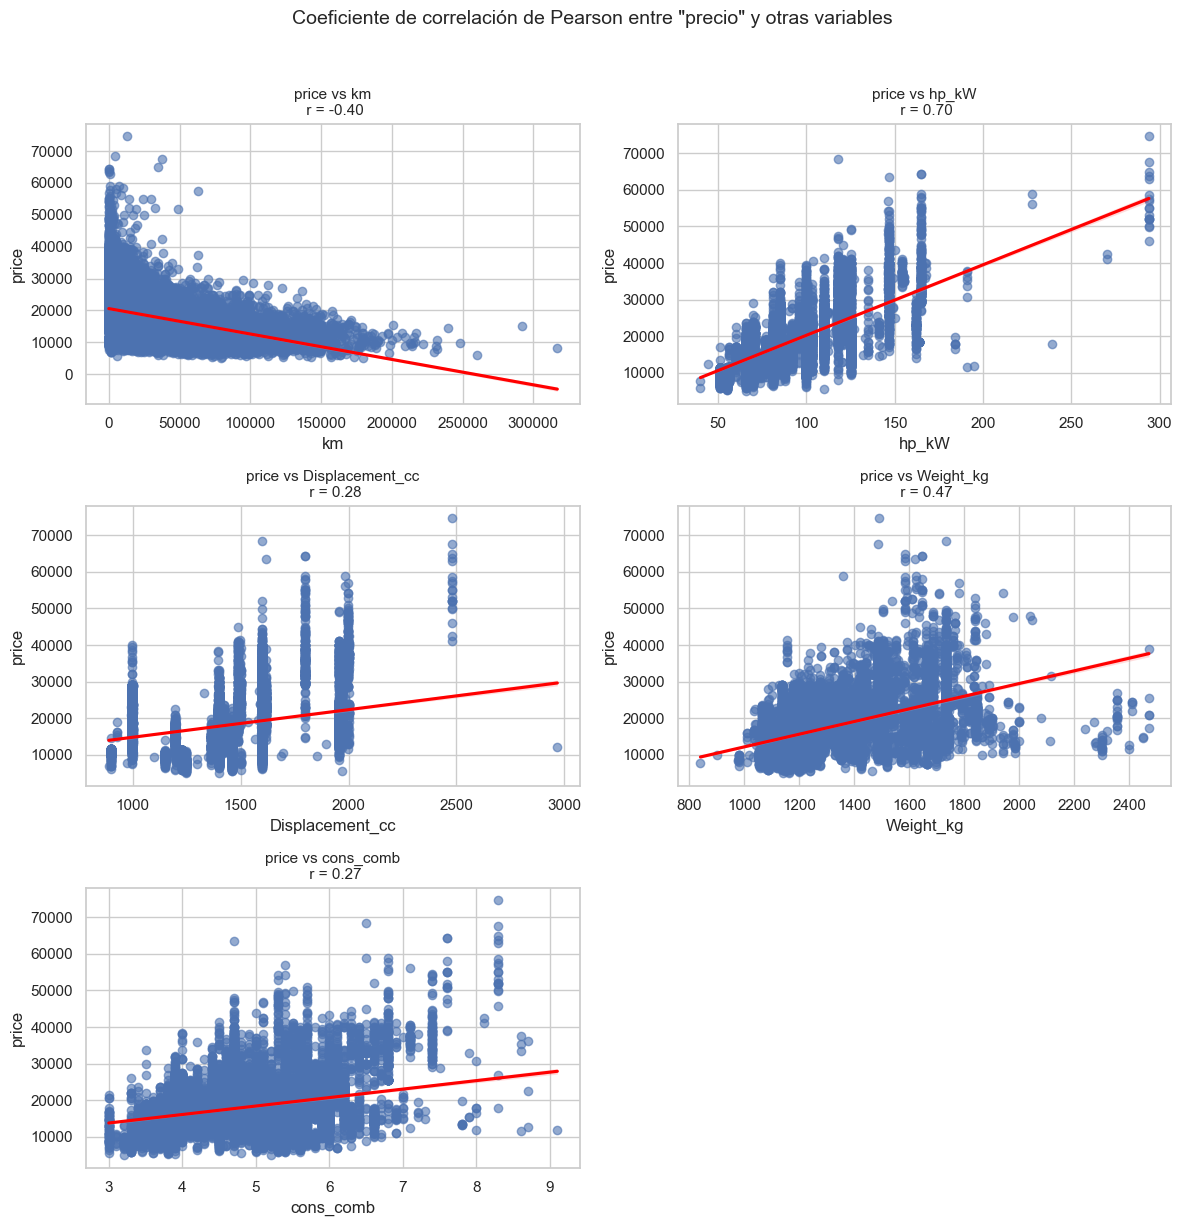

In [32]:

# Variables
variables = ['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']  
target = 'price'

# Crear figura con 5 subgráficas (2 columnas)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

# Iterar sobre las variables
for i, var in enumerate(variables):
    x = df[var]
    y = df[target]
    
    # Calcular correlación de Pearson
    r, _ = pearsonr(x, y)
    
    # Gráfico de dispersión con línea de regresión
    sns.regplot(x=x, y=y, ax=axes[i], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    
    # Título con valor de r
    axes[i].set_title(f'{target} vs {var}\n r = {r:.2f}', fontsize=11)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel(target)

# Eliminar subgráficas vacías si hay menos de 6
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Coeficiente de correlación de Pearson entre "precio" y otras variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Para dos variables numéricas continuas.

El coeficiente de Pearson (
) mide la fuerza y dirección de la relación lineal entre dos variables cuantitativas (Field, 2018).pdf).

Su valor oscila entre -1 y +1:

r = +1 → correlación positiva perfecta.
r = -1 → correlación negativa perfecta.
r = 0 → ausencia de correlación lineal.

## <span style="color:Blue;"><strong>5. Interpretaciones iniciales</strong></span>


<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;"> 
<b>¿Qué tendencias o patrones básicos se observan?</b>
<ul> 
  <li>El precio promedio de los autos es de 18.024 dolares.</li>
  <li>La mayoría de los precios se encuentran entre 10.000 y 30.000 dolares.</li>
  <li>La mayoría de los autos tienen entre 0 a 50.000 km.</li>
  <li>El tipo de combustible predominante es la gasolina, seguido por el diésel.</li> 
  <li>La edad de los vehiculos se distribuye casi uniformente igual entre las edades de 0 a 3 años .</li> 
  <li>La mayoría de los autos son usados.</li> 
  <li>El precio tiende a decrecer con el aumento del kilometraje y tipo de auto.</li> 
</ul> 
</div> 

<br> 

<div style="background-color:#E8F5E9; padding:10px; border-radius:8px;"> 
<b>¿Qué limitaciones tiene la base de datos?</b> 
<ul> 
    <li>No incluye información detallada sobre el estado real del vehículo como accidentes o mantenimiento realizados.</li> 
    <li>Puede haber un sesgo hacia ciertas regiones donde la compañia AutoScout24 tiene más presencia.</li> 
    <li>Los precios corresponden a anuncios, no necesariamente a precios finales de venta.</li> 
    <li>No se especifica si los autos nuevos provienen de concesionarios oficiales o vendedores particulares.</li> 
</ul> 
</div> 

<br> 

<div style="background-color:#FFF9C4; padding:10px; border-radius:8px;"> 
<b>¿Qué hipótesis iniciales podrían plantearse para análisis posteriores?</b> 
<ul> 
    <li>El kilometraje tiene una relación negativa con el precio: a mayor kilometraje, menor precio.</li> 
    <li>Los autos con menos años tienden a presentar precios más altos que los de mas años de uso.</li> 
    <li>El tipo de combustible (gasolina vs. diésel) influye en el precio del vehículo.</li> 
    <li>La transmisión automática podría estar asociada a precios más altos que la mecánica.</li> 
</ul> 
</div>

## <span style="color:Blue;"><strong>6. Conclusiones</strong></span>
<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;"> 
<b>- Resumen de los principales hallazgos iniciales.</b><br> 
<b>- Reflexión sobre cómo este entregable contribuye al desarrollo del proyecto completo.</b><br> 
</div>

- Se identificó una relación negativa entre el kilometraje y el precio de los vehículos, lo que confirma que el desgaste por uso reduce el valor de mercado.
- Las observaciones exploratorias permitieron detectar patrones relevantes:
  - Los autos más nuevos presentan precios considerablemente más altos.
  - Los vehículos utilizan primordialmente gasolina y diesel; una proporción muy pequeña gas y electricidad. 
  - A mayor edad del auto, menor es el precio de venta, lo que se observa con la relación negativa entre el precio y la edad del vehículo.
- Este entregable aporta un primer diagnóstico del mercado automotriz en AutoScout24 durante 2019 y sienta las bases para un análisis más profundo.

## <span style="color:black;"><strong>Análisis Univariado</strong></span>

### <span style="color:red;"><strong>Interpretación</strong></span>

La media y la mediana son muy similares lo cual indica que la distribución de los precios es bastante simétrica, y no está fuertemente sesgada hacia un lado.
La moda es más baja, con un valor de 3 mil pesos lo que muestra que hay cierta concentración de precios menores al promedio, aunque la mayoría se agrupa alrededor de 4 mil pesos.

La muestra de 100 precios simulada refleja unos precios centrados en 4 mil pesos, pero con una tendencia ligera hacia valores menores, lo cual puede interpretarse como la existencia de un segmento con salarios bajos dentro de la población.

En el histograma, se observa una concentración importante de salarios alrededor de 4 mil pesos, pero también una presencia significativa de valores pequeños, lo que genera que la moda este abajo de la media y la mediana.

### <span style="color:red;"><strong>Interpretación</strong></span>

- El rango muestra la amplitud total entre el precio más bajo y el más alto, en este caso entre 0 y 9.

- La Varianza mide la variabilidad global de los datos, los valores altos de la muestra simulada implica que los precios están más dispersos.

- La Desviación estándar indica cuánto, en promedio, se alejan los precios de la media. Para la simulación de 100 datos, en promedio, los precios se desvían ±1.98 mil pesos de la media (3.96).

- El Coeficiente de variación (CV) permite comparar la dispersión relativa; para un CV bajo (<20%) indica que los precios son bastante homogéneos respecto a la media. Para los datos simulados, este significa que la dispersión equivale a la mitad del valor promedio, lo que indica que los datos son moderadamente variables, no tan concentrados, pero tampoco totalmente dispersos.

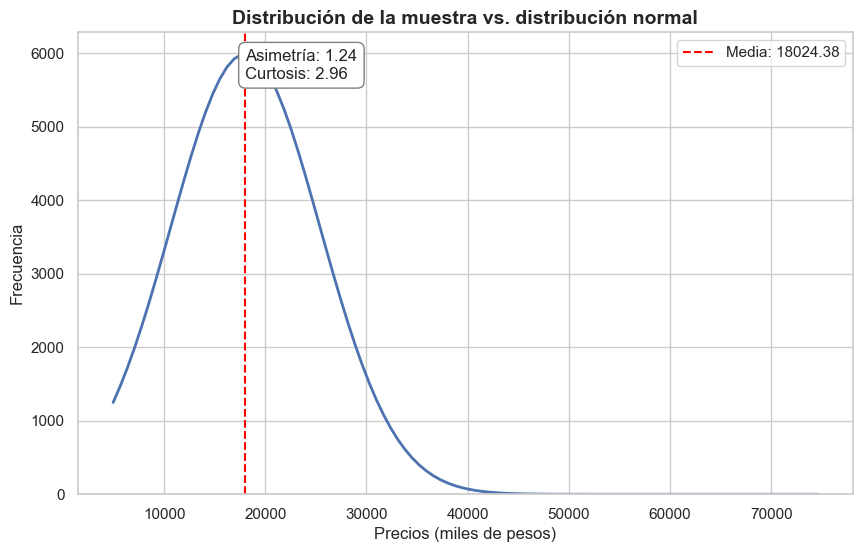

In [33]:
from scipy.stats import skew, kurtosis, norm

# Estilo visual
sns.set_theme(style="whitegrid")

# Cálculo de métricas
asimetria = skew(df['price'])
curtosis_valor = kurtosis(df['price'], fisher=True)

# Visualización con kde=false 
plt.figure(figsize=(10,6))
sns.histplot(df['price'], kde=False, color="skyblue", bins=10, stat="frequency", alpha=0.6)

# Curva normal con la media y la desviación de los datos generados
x = np.linspace(min(df['price']), max(df['price']), 100)
plt.plot(x, norm.pdf(x, media, desviacion) * len(df['price']) * (max(df['price'])-min(df['price']))/10,"b-", lw=2) 

# Línea en la media
plt.axvline(media, color="red", linestyle="--", label=f"Media: {media:.2f}")

# Anotaciones 
plt.text(media+0.5, max(plt.gca().get_ylim())*0.9,
         f"Asimetría: {asimetria:.2f}\nCurtosis: {curtosis_valor:.2f}",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray"))

# Títulos
plt.title("Distribución de la muestra vs. distribución normal", fontsize=14, fontweight="bold")
plt.xlabel("Precios (miles de pesos)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


### <span style="color:red;"><strong>Interpretación</strong></span>

- La Asimetría tiene un valor de 0.43, al ser un valor positivo y cercano a cero, indica que la distribución presenta una ligera inclinación hacia la derecha. Esto significa que la mayoría de los valores se concentran alrededor de la media, pero existen algunos precios más altos que generan una pequeña cola extendida hacia los valores grandes. Sin embargo, al no superar 1, el sesgo es bajo y la distribución puede considerarse casi simétrica.

- La Curtosis tiene un valor de 0.04, valor que está muy próximo a 0, lo que implica que la distribución es mesocúrtica, es decir, tiene una distribución parecida a la de una distribución normal.

### <span style="color:#2F749F;"><strong>Ejercicio 5: Análisis de correlación</strong></span>

En esta segunda parte, genera **dos variables** a partir de tú número de cédula y realiza un análisis **bivariado** para calcular la relación entre ellas.

1. Use los **6 últimos dígitos** de su cédula como base (similar al Ejercicio 1).  
2. Genere dos variables aleatorias (ejemplo: `ingresos` y `gastos`) con distribución normal, usando esa base como **semilla reproducible**.  
3. Calcule los coeficientes de correlación de **Pearson** y **Spearman**. 
4. Grafique las variables analizadas (ver la imagen de ejemplo)
5. Interprete los resultados.  


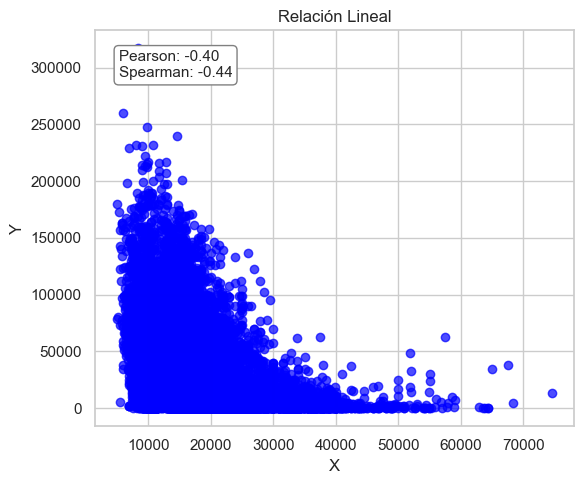

In [36]:
from scipy import stats


# Relación 
x = df['price']
y = df['km']

# Correlaciones
def calcular_correlaciones(x, y):
    pearson, _ = stats.pearsonr(x, y)
    spearman, _ = stats.spearmanr(x, y)
    return pearson, spearman

p1, s1 = calcular_correlaciones(x, y)

# Visualización comparativa
fig, ax = plt.subplots(figsize=(6, 5))

# Relación X1 vs Y1
ax.scatter(x, y, color="blue", alpha=0.7)
ax.set_title("Relación Lineal")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# Texto con coeficientes
texto = f"Pearson: {p1:.2f}\nSpearman: {s1:.2f}"
ax.text(0.05, 0.95, texto, transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"))

plt.tight_layout()
plt.show()

### <span style="color:red;"><strong>Interpretación</strong></span>

- El coefiente Pearson tiene un valor de 0.82, lo que indica una correlación lineal fuerte y positiva entre x e y, es decir que cuando una variable aumenta, la otra también tiende a aumentar de forma bastante consistente y como es cercano a uno positivo, los puntos se agrupan de forma ascendente.

- El coefiente de Spearman tiene un valor 0.83, este mide la relación monótona entre las dos variables y también es fuerte y positiva, lo que confirma que no solo existe una relación lineal, sino también una relación monótona.

### <span style="color:#2F749F;"><strong>Ejercicio 6: Chi-Cuadrado</strong></span>

En esta parte, analiza si existe **asociación estadística** entre dos variables categóricas simuladas a partir de tu número de cédula.

1. Usa los **6 últimos dígitos** de tu cédula como base para generar una semilla reproducible.
2. Simula una muestra de **60 personas** con dos variables categóricas:
   - `Nivel educativo`: Básico, Medio, Superior.
   - `Acceso a internet`: Sí, No.
3. Crea una **tabla de contingencia** entre ambas variables.
4. Aplica la **prueba de Chi cuadrado de independencia**.
5. Visualiza la distribución conjunta con un mapa de calor (ver la imagen de con la información de ejemplo).
6. Interpreta el resultado.

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# Base de la cédula
base = 60082
np.random.seed(base)

# Muestra de 60 personas
n = 60

# Variables cualitativas 
niveles = ["Básico", "Medio", "Superior"]
internet = ["Sí", "No"]

nivel_educativo = np.random.choice(niveles, size=n, p=[0.3, 0.4, 0.3])   
acceso_internet = np.random.choice(internet, size=n, p=[0.7, 0.3])       

# DataFrame
df = pd.DataFrame({
    "Nivel educativo": nivel_educativo,
    "Acceso a internet": acceso_internet
})

# Tabla de contingencia
tabla = pd.crosstab(df["Nivel educativo"], df["Acceso a internet"])
print("Tabla de contingencia:")
print(tabla)

# Chi-cuadrado 
chi2, p, dof, esperados = chi2_contingency(tabla)
print("\nResultados Chi-cuadrado:")
print(f"Chi2 = {chi2:.2f}, p-valor = {p:.4f}, grados de libertad = {dof}")
print("Frecuencias esperadas:\n",pd.DataFrame(esperados, index=tabla.index, columns=tabla.columns), "\n")


# Visualización (mapa de calor)
plt.figure(figsize=(6,4))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")
plt.title("Distribución conjunta: Nivel educativo vs Acceso a internet")
plt.show()

### <span style="color:red;"><strong>Interpretación</strong></span>

Partiendo de la hipótesis nula de que: El acceso a internet y el nivel educativo son independientes y la alternativa: Existe asociación entre el acceso a internet y el nivel educativo.
- p-valor = 0.1109, como es mayor que 0.05, no hay evidencia suficiente para rechazar la hipótesis nula; lo que, estadísticamente, no podemos afirmar que exista relación significativa entre el nivel educativo y el acceso a internet en esta muestra de 60 personas.
  
Diferencias entre mustras observadas y esperadas:
- En Básico sin internet: se esperaban 4, pero hubo 7, más de lo esperado.
- En Medio sin internet: se esperaban 5, pero hubo 3, menos de lo esperado.
- En Superior los valores observados y esperados están muy cerca.

# <div style="text-align:center; color:Blue; font-weight:bold;">Introducción al Proyecto de aula</div>
<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;">
<b>Pregunta de investigación</b>  
</div>
¿Cuáles son las principales variables que influyen en el precio de los autos publicados en la plataforma AutoScout24 durante el año 2019?
<br> 
<div style="background-color:#E8F5E9; padding:10px; border-radius:8px;">
<b> Relevancia del problema</b>
</div>

El **precio de los automóviles**, tanto nuevos como usados, es un indicador importante en el mercado automotriz, puesto que refleja las condiciones técnicas y de uso del vehículo. Analizar qué elementos determinan el valor de un auto es primordial, ya que permite a compradores y vendedores tomar decisiones más acertadas, a las empresas del sector diseñar estrategias comerciales más competitivas y a los analistas económicos entender mejor la dinámica del mercado.

Los aspectos más relevantes en el análisis de mercado, para evaluar el precio final de un auto son: **kilometraje**, **años de uso**, **la marca y el modelo**, **el tipo de combustible**, **la potencia del motor** y el **estado general del vehículo**. El análisis de cada ítem anterior y cómo interactúan entre sí, es de vital importancia para el estudio, especialmente en plataformas de compraventa en línea como AutoScout24, que concentran gran cantidad de información sobre precios reales de mercado.


<div style="background-color:#FFF9C4; padding:10px; border-radius:8px;">
<b> Relación entre el problema y la base de datos seleccionada. </b>  
</div>

La base de datos fue seleccionada de **[Car Price](https://www.kaggle.com/datasets/yaaryiitturan/auto-scout-car-price)**
disponible en la plataforma Kaggle. Este dataset recopila información de vehículos nuevos y usados ofertados en la compañía AutoScout24 durante el año 2019. Incluye variables técnicas y comerciales relevantes como la marca, modelo, años de uso, kilometraje, tipo de combustible, potencia del motor, transmisión, entre otras.

Mediante las variables disponibles en la base datos, es posible realizar un análisis de cuáles de estas características se asocian de manera más significativa con el precio final de los autos, permitiendo responder a la pregunta de investigación planteada y aportar evidencia sobre los factores que más influyen en la valoración del mercado automotriz.


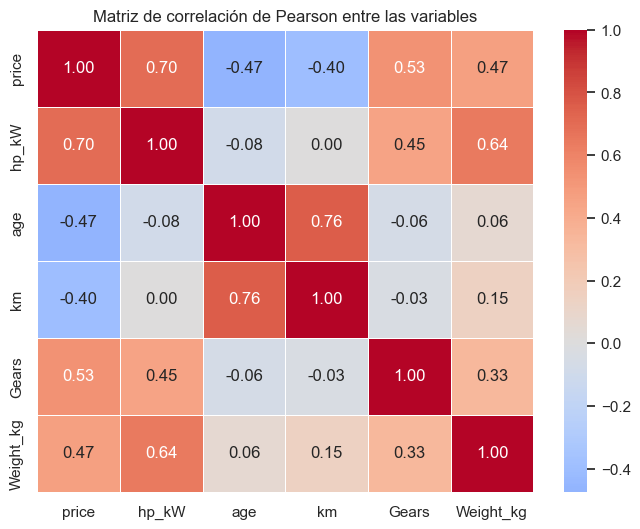

In [27]:
# Seleccionar solo las variables numéricas de interés
variables = ['price', 'hp_kW', 'age', 'km', 'Gears', 'Weight_kg']  
df_seleccion = df[variables]

# Matriz de correlación de Pearson
corr = df_seleccion.corr(method='pearson')

# Gráfico de mapa de calor
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de correlación de Pearson entre las variables")
plt.show()


### Analisis multivariado

Varianza explicada por componente (%):
PC1: 45.64%
PC2: 26.53%
PC3: 12.79%
PC4: 6.80%
PC5: 5.82%
PC6: 2.42%


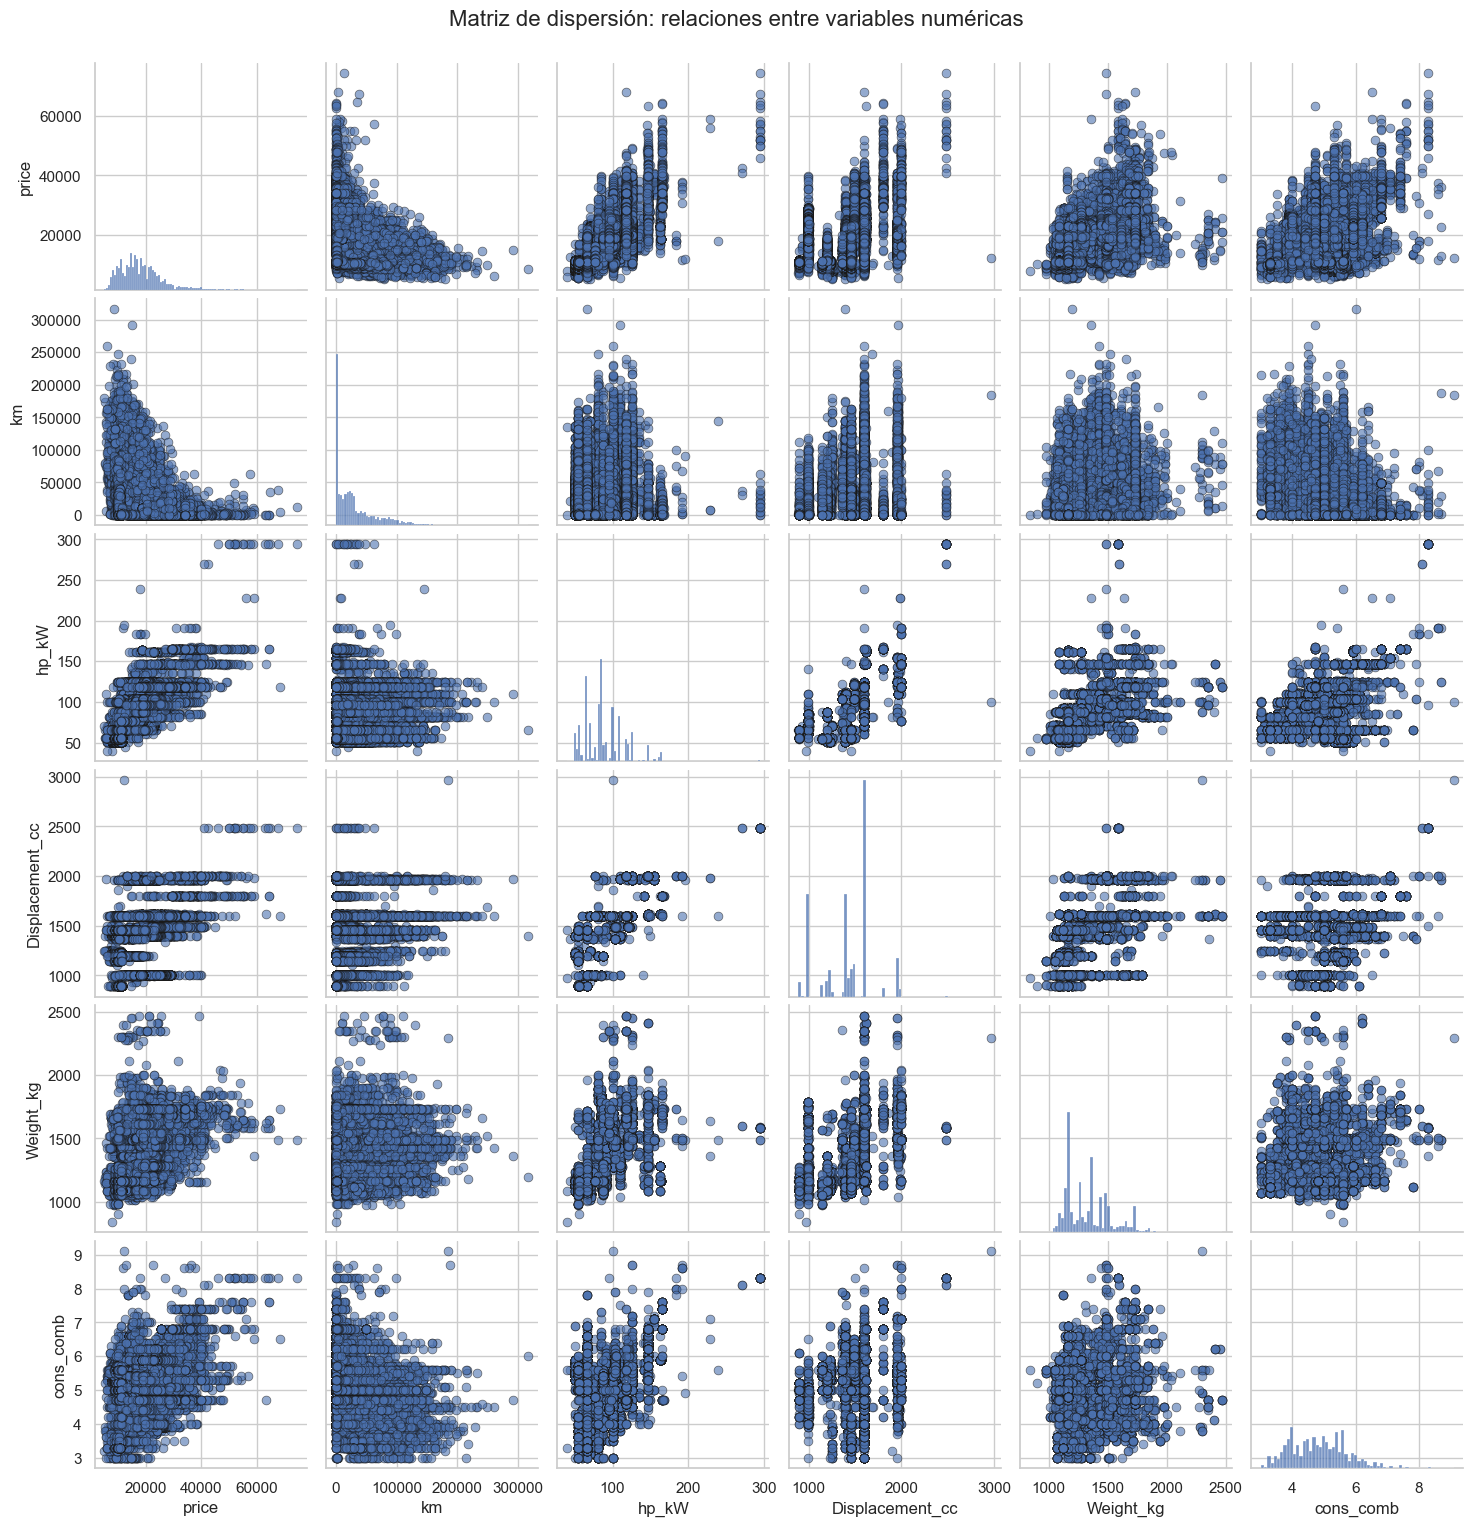

In [31]:


# Lista de tus variables numéricas
variables_numericas = ['price', 'km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']

# 1️⃣ Estandarizar variables
scaler = StandardScaler()
X_std = scaler.fit_transform(df[variables_numericas])

# 2️⃣ PCA (Análisis de Componentes Principales)
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Crear DataFrame con los componentes principales
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

# Mostrar varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_ * 100
print("Varianza explicada por componente (%):")
for i, var in enumerate(varianza_explicada):
    print(f"PC{i+1}: {var:.2f}%")

# 3️⃣ Matriz de dispersión con tus variables originales
sns.pairplot(df[variables_numericas], diag_kind='hist', corner=False,
             plot_kws={'alpha':0.6, 's':40, 'edgecolor':'k'})
plt.suptitle('Matriz de dispersión: relaciones entre variables numéricas', fontsize=16, y=1.02)
plt.show()


sns.pairplot(df, hue='species', palette='Set2', diag_kind='hist', corner=False)
plt.suptitle('Matriz de dispersión: relaciones entre variables del Iris', fontsize=16, y=1.02)
plt.show()


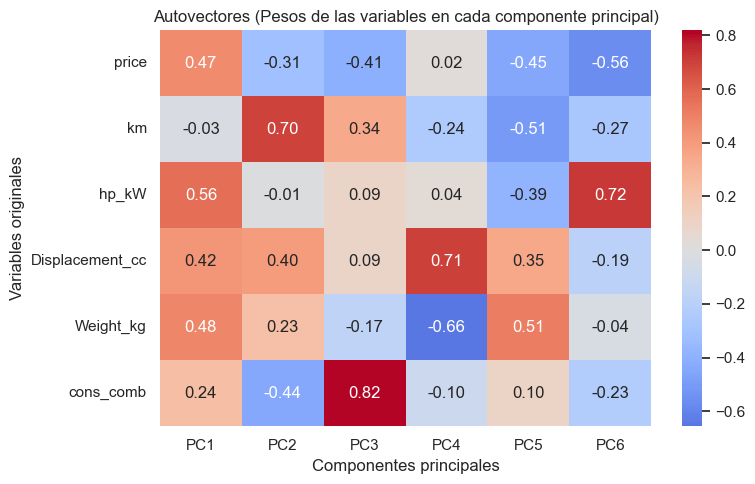

Ecuaciones de los componentes principales:

PC1 = 0.467·'price' + -0.032·'km' + 0.562·'hp_kW' + 0.423·'Displacement_cc' + 0.479·'Weight_kg' + 0.238·'cons_comb'
PC2 = -0.314·'price' + 0.701·'km' + -0.007·'hp_kW' + 0.398·'Displacement_cc' + 0.23·'Weight_kg' + -0.445·'cons_comb'
PC3 = -0.41·'price' + 0.342·'km' + 0.092·'hp_kW' + 0.088·'Displacement_cc' + -0.17·'Weight_kg' + 0.818·'cons_comb'
PC4 = 0.022·'price' + -0.242·'km' + 0.039·'hp_kW' + 0.706·'Displacement_cc' + -0.655·'Weight_kg' + -0.105·'cons_comb'
PC5 = -0.45·'price' + -0.507·'km' + -0.39·'hp_kW' + 0.347·'Displacement_cc' + 0.508·'Weight_kg' + 0.098·'cons_comb'
PC6 = -0.558·'price' + -0.273·'km' + 0.723·'hp_kW' + -0.187·'Displacement_cc' + -0.039·'Weight_kg' + -0.234·'cons_comb'


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Variables numéricas seleccionadas
variables_numericas = ['price', 'km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']

# 1️⃣ Estandarización
scaler = StandardScaler()
X_std = scaler.fit_transform(df[variables_numericas])

# 2️⃣ PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)

# 3️⃣ Matriz de componentes (autovectores)
componentes = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(variables_numericas))],
    index=variables_numericas
)

# 4️⃣ Visualización de autovectores
plt.figure(figsize=(8, 5))
sns.heatmap(componentes, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Autovectores (Pesos de las variables en cada componente principal)')
plt.ylabel('Variables originales')
plt.xlabel('Componentes principales')
plt.tight_layout()
plt.show()

# 5️⃣ Ecuaciones de los componentes principales
print("Ecuaciones de los componentes principales:\n")
for i, comp in enumerate(componentes.columns):
    pesos = pca.components_[i]
    ecuacion = " + ".join([f"{round(pesos[j], 3)}·'{variables_numericas[j]}'" for j in range(len(pesos))])
    print(f"{comp} = {ecuacion}")


📋 Tabla de varianza explicada:

  Componente  Autovalor    PVE  PVE acumulada
0        PC1      2.739  0.456          0.456
1        PC2      1.592  0.265          0.722
2        PC3      0.767  0.128          0.850
3        PC4      0.408  0.068          0.918
4        PC5      0.349  0.058          0.976
5        PC6      0.145  0.024          1.000


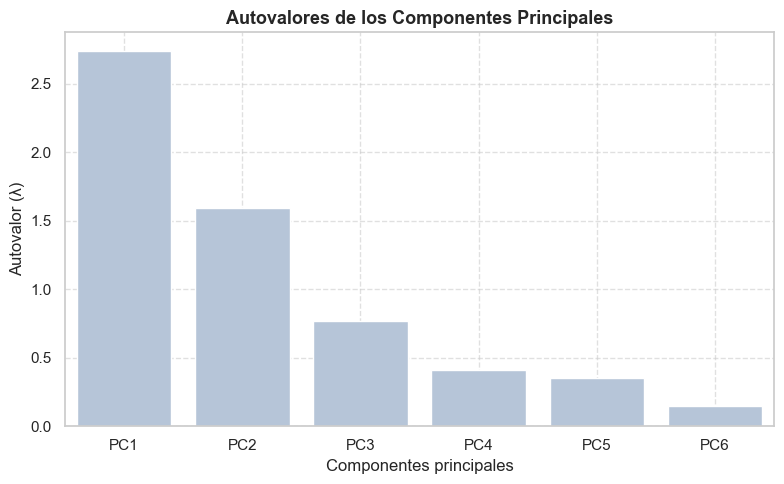

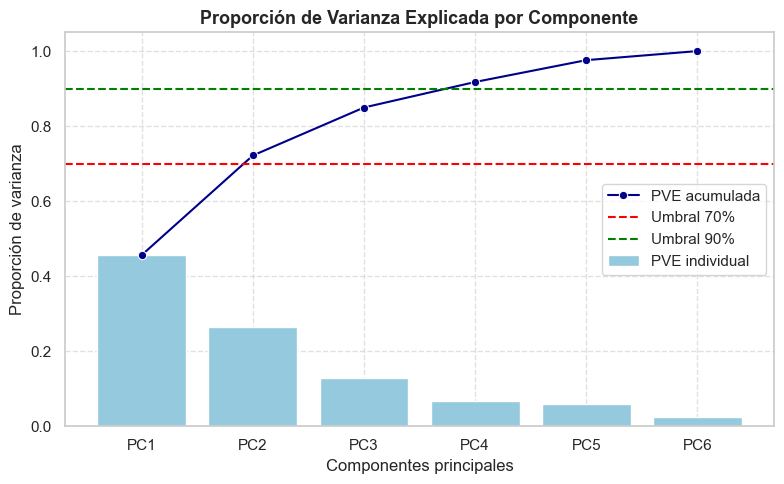

In [34]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Variables numéricas seleccionadas
variables_numericas = ['price', 'km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']

# Estandarización
scaler = StandardScaler()
X_std = scaler.fit_transform(df[variables_numericas])

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)

# ==============================
# 📈 VARIANZA EXPLICADA
# ==============================

# Autovalores y proporción de varianza explicada
varianza = pca.explained_variance_
PVE = pca.explained_variance_ratio_
PVE_acum = np.cumsum(PVE)
componentes = [f'PC{i+1}' for i in range(len(PVE))]

# Crear DataFrame
df_varianza = pd.DataFrame({
    'Componente': componentes,
    'Autovalor': varianza,
    'PVE': PVE,
    'PVE acumulada': PVE_acum
})

# Mostrar tabla con resultados
print("📋 Tabla de varianza explicada:\n")
print(df_varianza.round(3))

# ==============================
# 🔹 Gráfico de Autovalores
# ==============================
plt.figure(figsize=(8, 5))
sns.barplot(x='Componente', y='Autovalor', data=df_varianza, color='lightsteelblue')
plt.title('Autovalores de los Componentes Principales', fontsize=13, weight='bold')
plt.ylabel('Autovalor (λ)')
plt.xlabel('Componentes principales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==============================
# 🔹 Gráfico de PVE y PVE Acumulada
# ==============================
plt.figure(figsize=(8, 5))
sns.barplot(x='Componente', y='PVE', data=df_varianza, color='skyblue', label='PVE individual')
sns.lineplot(x='Componente', y='PVE acumulada', data=df_varianza, marker='o', color='darkblue', label='PVE acumulada')
plt.axhline(0.7, color='red', linestyle='--', label='Umbral 70%')
plt.axhline(0.9, color='green', linestyle='--', label='Umbral 90%')
plt.title('Proporción de Varianza Explicada por Componente', fontsize=13, weight='bold')
plt.ylabel('Proporción de varianza')
plt.xlabel('Componentes principales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


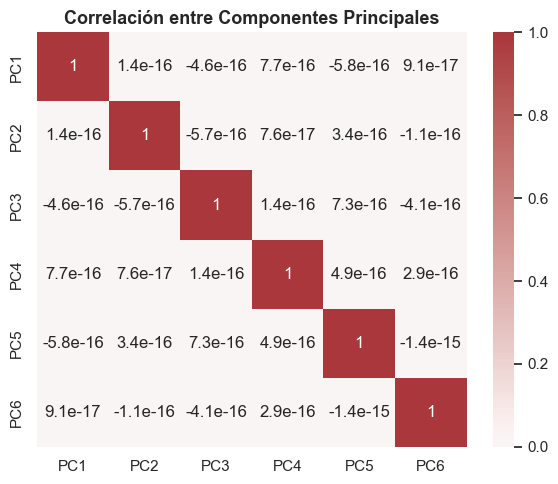

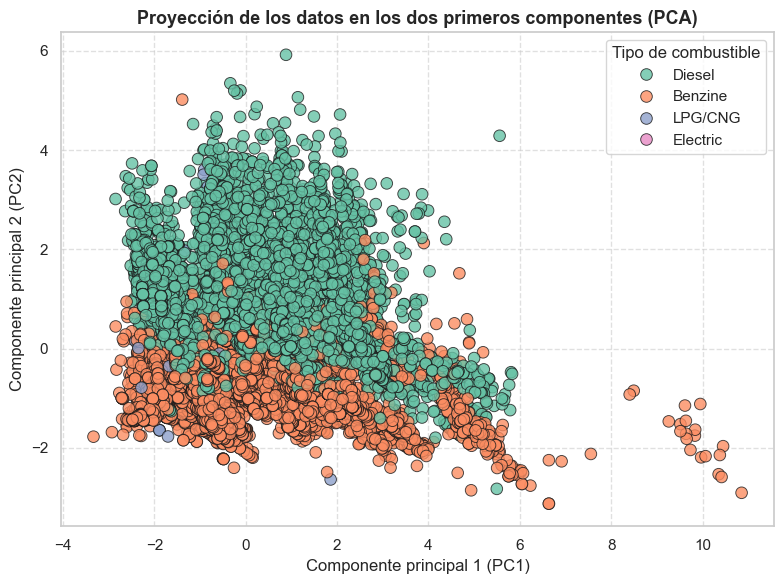

In [36]:
# ======================================
# 📊 Correlación entre componentes PCA
# ======================================
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(len(PVE))])
correlaciones = df_pca.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlaciones, annot=True, cmap='vlag', center=0)
plt.title('Correlación entre Componentes Principales', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# ======================================
# 🎯 Proyección en los dos primeros componentes
# ======================================
# Agregar una variable categórica para colorear (puedes cambiar 'Fuel' por otra)
df_pca['Fuel'] = df['Fuel']

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1', y='PC2',
    hue='Fuel',  # variable categórica
    palette='Set2',
    alpha=0.8,
    s=70,
    edgecolor='k'
)
plt.title('Proyección de los datos en los dos primeros componentes (PCA)', fontsize=13, weight='bold')
plt.xlabel('Componente principal 1 (PC1)')
plt.ylabel('Componente principal 2 (PC2)')
plt.legend(title='Tipo de combustible', loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Regresión Lineal Múltiple

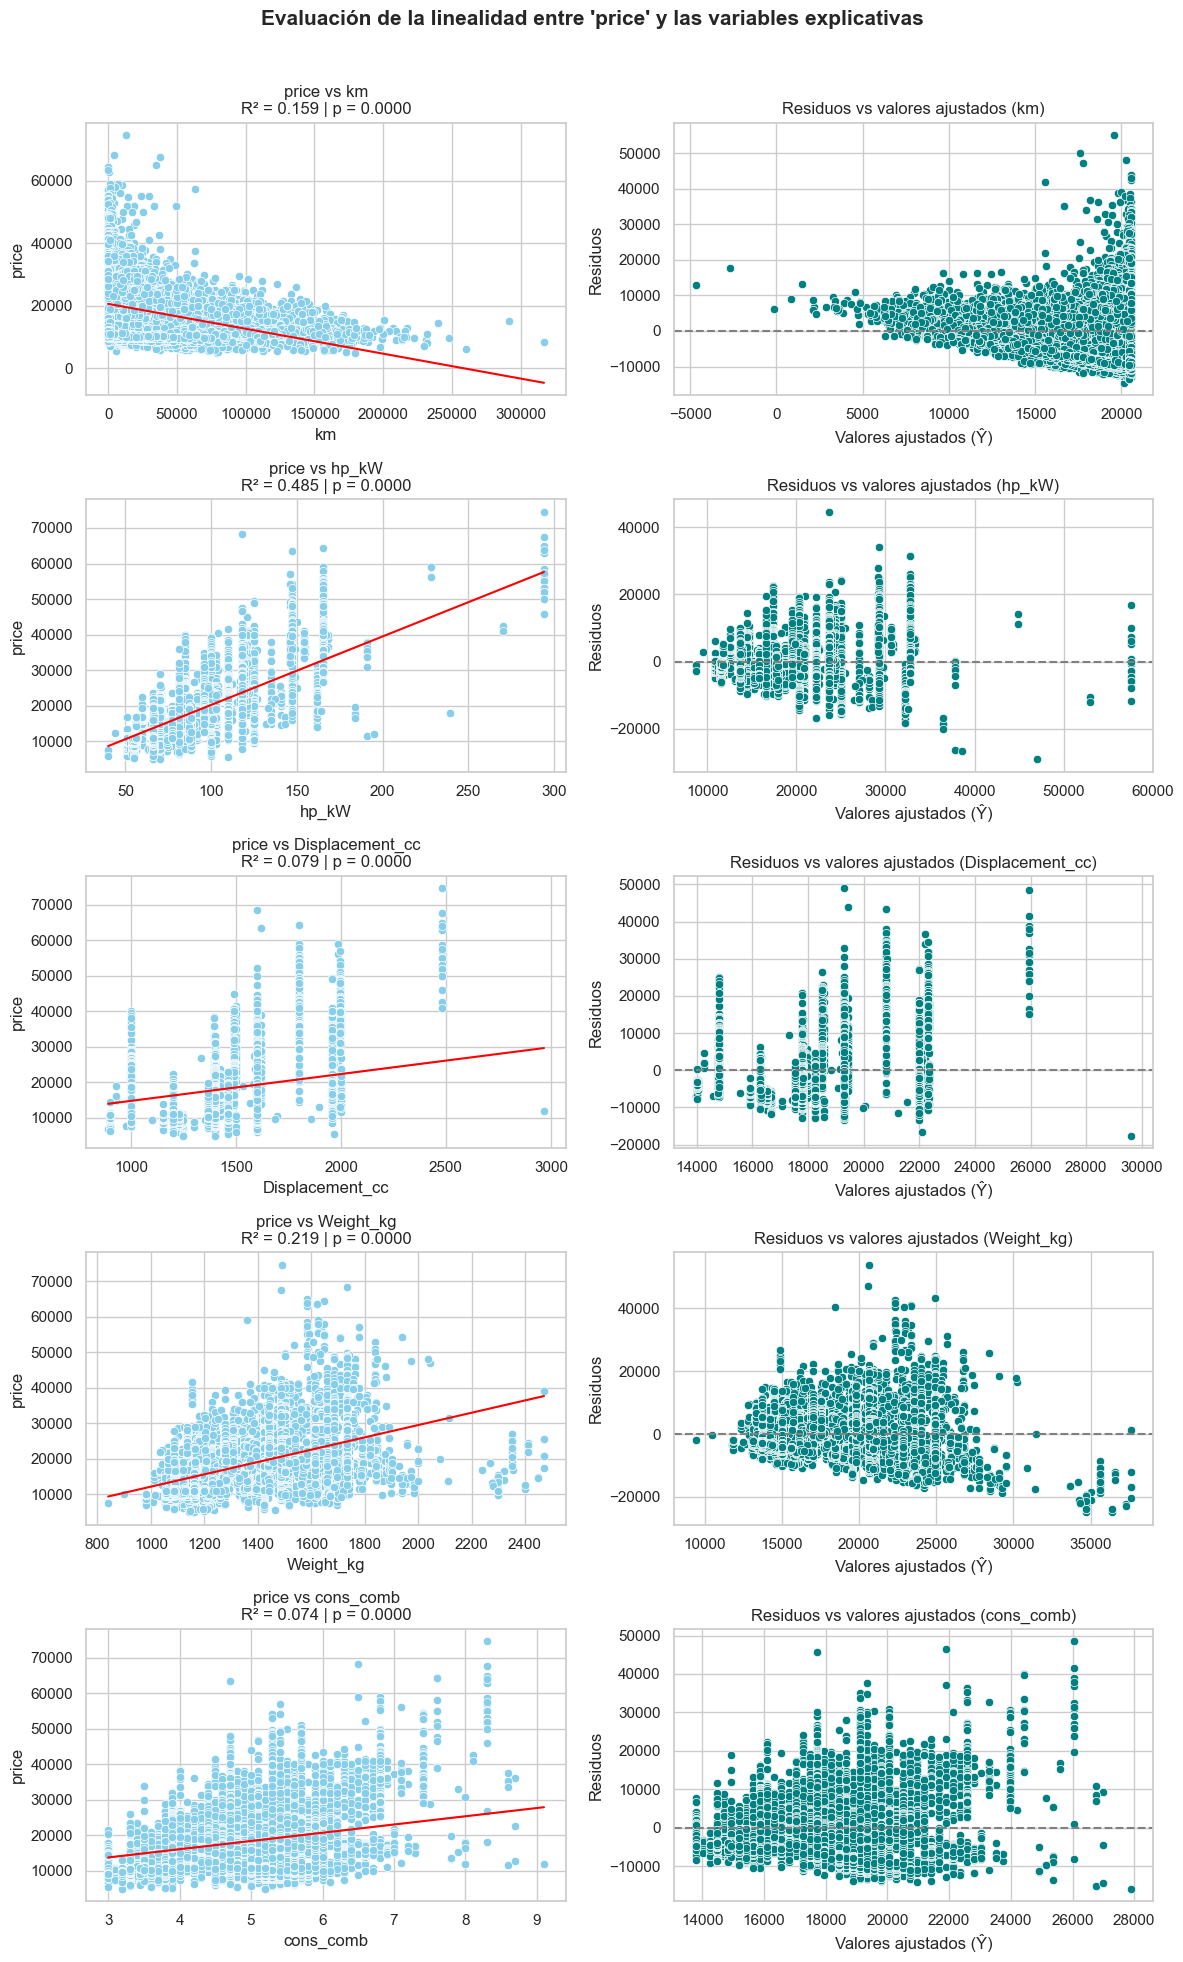

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Variables
target = 'price'
predictoras = [ 'km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']

# Configuración general de visualización
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(len(predictoras), 2, figsize=(12, 4*len(predictoras)))
fig.subplots_adjust(wspace=0.3, hspace=0.4)

# Iterar sobre cada variable predictora
for i, var in enumerate(predictoras):
    X = sm.add_constant(df[var])  # Agregar constante
    y = df[target]

    # Ajustar modelo lineal simple
    modelo = sm.OLS(y, X).fit()

    # -------------------------
    # (1) Dispersión + ajuste
    # -------------------------
    sns.scatterplot(x=df[var], y=y, color='skyblue', ax=axes[i, 0])
    sns.lineplot(x=df[var], y=modelo.fittedvalues, color='red', ax=axes[i, 0])
    axes[i, 0].set_title(f"{target} vs {var}\nR² = {modelo.rsquared:.3f} | p = {modelo.pvalues[var]:.4f}")
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel(target)

    # -------------------------
    # (2) Residuos
    # -------------------------
    sns.scatterplot(x=modelo.fittedvalues, y=modelo.resid, color='teal', ax=axes[i, 1])
    axes[i, 1].axhline(0, color='gray', linestyle='--')
    axes[i, 1].set_title(f"Residuos vs valores ajustados ({var})")
    axes[i, 1].set_xlabel("Valores ajustados (Ŷ)")
    axes[i, 1].set_ylabel("Residuos")

plt.suptitle("Evaluación de la linealidad entre 'price' y las variables explicativas", fontsize=15, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     6657.
Date:                Mon, 13 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:26:21   Log-Likelihood:            -1.5535e+05
No. Observations:               15915   AIC:                         3.107e+05
Df Residuals:                   15909   BIC:                         3.108e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            5916.5637    331.573     

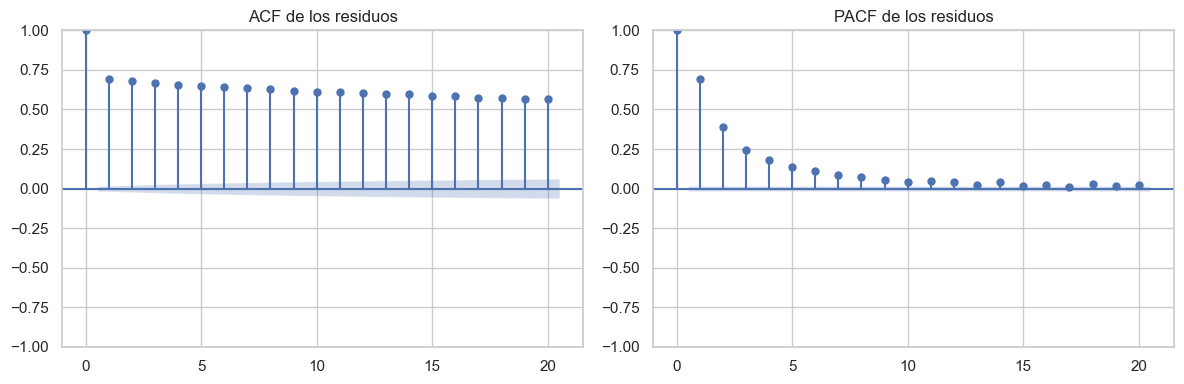

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- VARIABLES DEL MODELO ---
# Variable dependiente y explicativas
y = df['price']
X = df[['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']]

# --- MODELO DE REGRESIÓN LINEAL MÚLTIPLE ---
X_const = sm.add_constant(X)  # agrega la constante (intercepto)
model = sm.OLS(y, X_const).fit()

# --- RESULTADOS ---
print(model.summary())

# --- RESIDUOS ---
resid = model.resid

# --- PRUEBA DE DURBIN-WATSON ---
dw = durbin_watson(resid)
print(f"\nDurbin-Watson: {dw:.3f}")
if dw < 1.5:
    print("→ Posible autocorrelación positiva de los residuos.")
elif dw > 2.5:
    print("→ Posible autocorrelación negativa de los residuos.")
else:
    print("→ No hay evidencia fuerte de autocorrelación.")

# --- GRÁFICOS ACF y PACF ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid, ax=axes[0], lags=20)
axes[0].set_title("ACF de los residuos")
plot_pacf(resid, ax=axes[1], lags=20)
axes[1].set_title("PACF de los residuos")
plt.tight_layout()
plt.show()


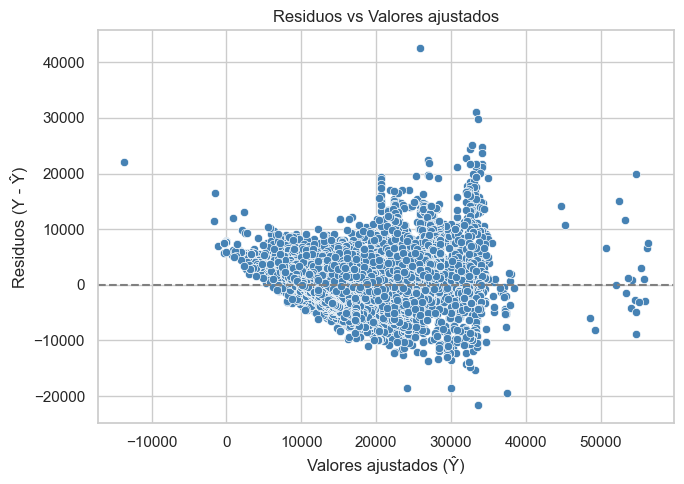

📊 Prueba de Breusch–Pagan:
LM Statistic: 1568.099
p-valor: 0.0000
→ Posible heterocedasticidad (varianza de los errores no constante).


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# --- VARIABLES ---
y = df['price']
X = df[['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']]

# --- MODELO ---
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

# --- RESIDUOS Y VALORES AJUSTADOS ---
resid = model.resid
fitted = model.fittedvalues

# --- GRÁFICO DE RESIDUOS ---
plt.figure(figsize=(7, 5))
sns.scatterplot(x=fitted, y=resid, color='steelblue')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Residuos vs Valores ajustados")
plt.xlabel("Valores ajustados (Ŷ)")
plt.ylabel("Residuos (Y - Ŷ)")
plt.tight_layout()
plt.show()

# --- PRUEBA DE BREUSCH–PAGAN ---
bp_test = het_breuschpagan(resid, X_const)
labels = ['LM Statistic', 'p-value', 'f-value', 'f p-value']
bp_results = dict(zip(labels, bp_test))

print("📊 Prueba de Breusch–Pagan:")
print(f"LM Statistic: {bp_results['LM Statistic']:.3f}")
print(f"p-valor: {bp_results['p-value']:.4f}")

if bp_results['p-value'] > 0.05:
    print("→ No hay evidencia de heterocedasticidad (varianza constante de los errores).")
else:
    print("→ Posible heterocedasticidad (varianza de los errores no constante).")


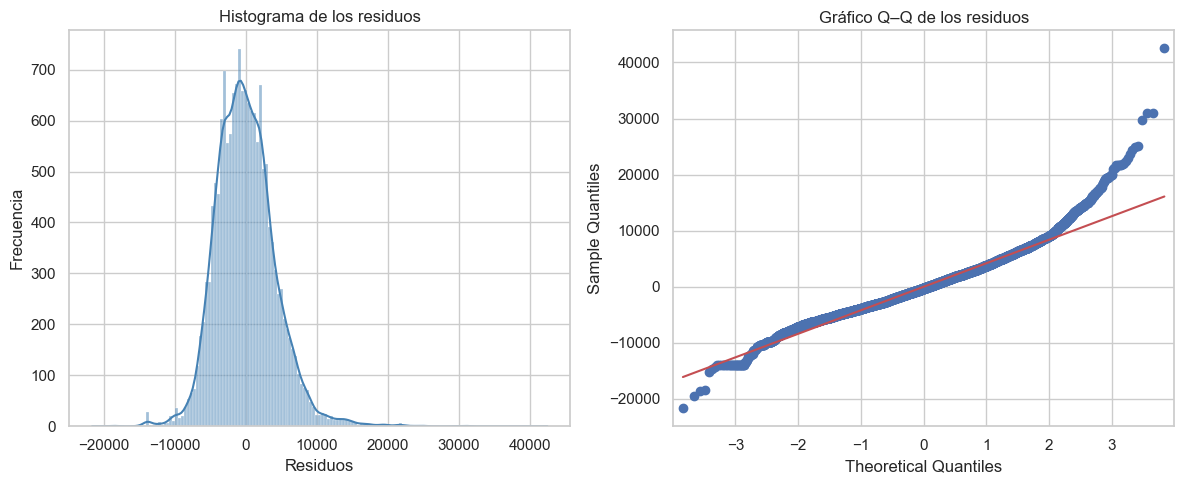

📊 Prueba de Shapiro–Wilk:
Estadístico W = 0.9700
p-valor = 0.0000
→ No se cumple el supuesto de normalidad ⚠️


C:\Users\Nitro V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15915.
  res = hypotest_fun_out(*samples, **kwds)


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.graphics.gofplots import qqplot

# --- VARIABLES ---
y = df['price']
X = df[['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']]

# --- MODELO ---
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
resid = model.resid

# --- VISUALIZACIÓN DE NORMALIDAD ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma de residuos
sns.histplot(resid, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Histograma de los residuos")
axes[0].set_xlabel("Residuos")
axes[0].set_ylabel("Frecuencia")

# Gráfico Q–Q (Quantile-Quantile)
qqplot(resid, line='s', ax=axes[1])
axes[1].set_title("Gráfico Q–Q de los residuos")

plt.tight_layout()
plt.show()

# --- PRUEBA DE NORMALIDAD ---
stat, p_value = shapiro(resid)
print("📊 Prueba de Shapiro–Wilk:")
print(f"Estadístico W = {stat:.4f}")
print(f"p-valor = {p_value:.4f}")

if p_value > 0.05:
    print("→ Se asume normalidad en los residuos ✅")
else:
    print("→ No se cumple el supuesto de normalidad ⚠️")

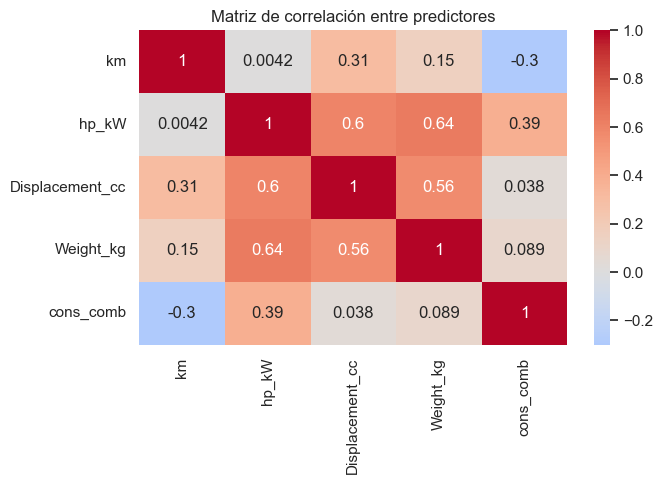

📊 Factores de inflación de varianza (VIF):
          Variable        VIF
0            const  99.259946
1               km   1.252306
2            hp_kW   2.559685
3  Displacement_cc   1.962765
4        Weight_kg   1.900706
5        cons_comb   1.382357 

📈 Índice de condición: 490028.87

🔍 Interpretación:
- VIF ≈ 1: Sin colinealidad
- 1 < VIF < 5: Colinealidad moderada (aceptable)
- VIF ≥ 10: Problema serio de multicolinealidad ⚠️
- Índice de condición < 10: Bien ✅
- 10–30: Colinealidad moderada ⚠️
- > 30: Colinealidad severa 🚨


In [42]:


# --- Variables predictoras ---
X = df[['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']]

# --- MATRIZ DE CORRELACIÓN ---
plt.figure(figsize=(7, 5))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Matriz de correlación entre predictores")
plt.tight_layout()
plt.show()

# --- FUNCIÓN PARA CALCULAR VIF ---
def calcular_vif(X):
    X_const = sm.add_constant(X)
    vif = pd.DataFrame()
    vif["Variable"] = X_const.columns
    vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    return vif

# --- CÁLCULO DEL VIF ---
vif_df = calcular_vif(X)
print("📊 Factores de inflación de varianza (VIF):")
print(vif_df, "\n")

# --- ÍNDICE DE CONDICIÓN ---
def calcular_indice_condicion(X):
    X_const = sm.add_constant(X)
    _, s, _ = svd(X_const)
    return max(s) / min(s)

indice_cond = calcular_indice_condicion(X)
print(f"📈 Índice de condición: {indice_cond:.2f}")

# --- INTERPRETACIÓN ---
print("\n🔍 Interpretación:")
print("- VIF ≈ 1: Sin colinealidad")
print("- 1 < VIF < 5: Colinealidad moderada (aceptable)")
print("- VIF ≥ 10: Problema serio de multicolinealidad ⚠️")
print("- Índice de condición < 10: Bien ✅")
print("- 10–30: Colinealidad moderada ⚠️")
print("- > 30: Colinealidad severa 🚨")


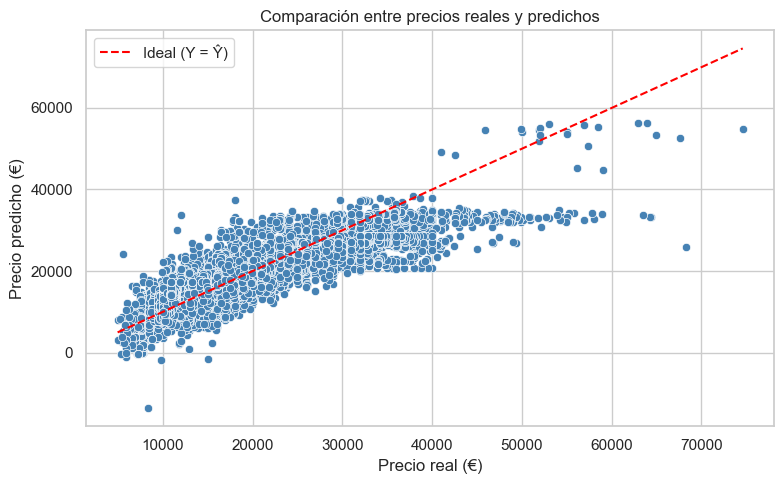

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     6657.
Date:                Mon, 13 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:43:05   Log-Likelihood:            -1.5535e+05
No. Observations:               15915   AIC:                         3.107e+05
Df Residuals:                   15909   BIC:                         3.108e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            5916.5637    331.573     

In [43]:
# Variables predictoras y dependiente
X = df[['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']]
Y = df['price']

# Agregar constante para el intercepto
X_const = sm.add_constant(X)

# Ajustar modelo de regresión lineal múltiple
modelo = sm.OLS(Y, X_const).fit()

# --- Predicciones ---
Y_pred = modelo.predict(X_const)

# --- Evaluación visual ---
plt.figure(figsize=(8, 5))
sns.scatterplot(x=Y, y=Y_pred, color='steelblue')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], color='red', linestyle='--', label='Ideal (Y = Ŷ)')
plt.xlabel('Precio real (€)')
plt.ylabel('Precio predicho (€)')
plt.title('Comparación entre precios reales y predichos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Resultados del modelo ---
print(modelo.summary())


### Análisis de clúster

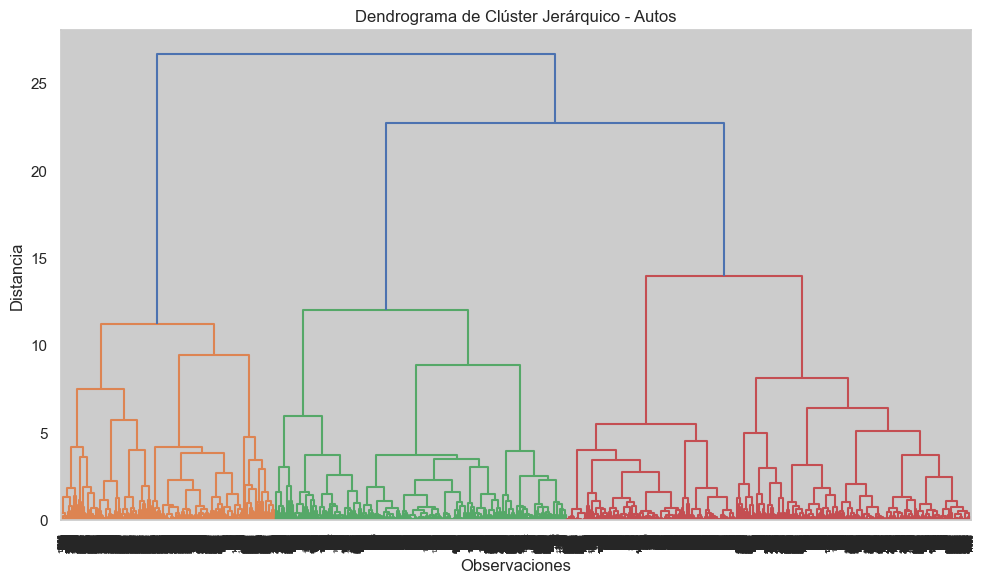

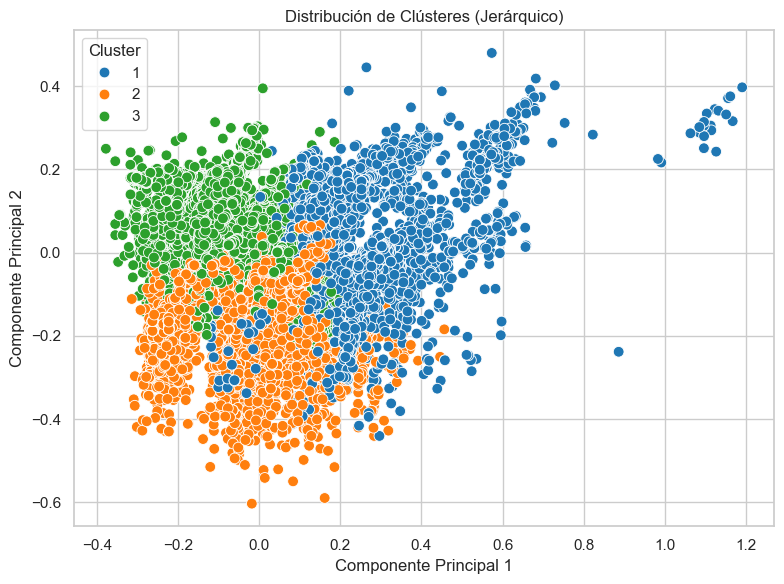

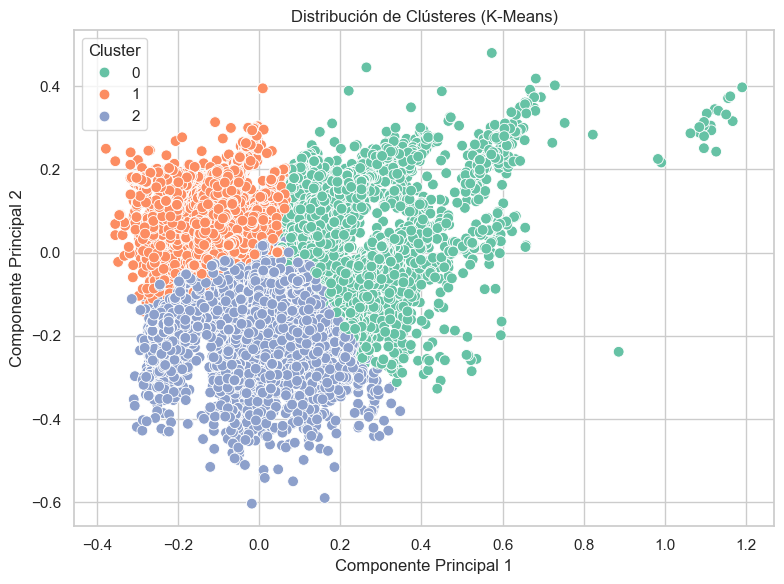

=== Promedios por clúster (K-Means) ===
                   price        km   hp_kW  Displacement_cc  Weight_kg  \
Cluster_KMeans                                                           
0               25657.18  22735.41  123.34          1652.03    1539.25   
1               15326.82  17008.90   71.48          1172.77    1194.92   
2               15994.84  55804.13   84.68          1573.55    1366.71   

                cons_comb  Cluster_Jerarquico   PC1   PC2  
Cluster_KMeans                                             
0                    5.62                1.19  0.27  0.06  
1                    5.08                2.98 -0.14  0.11  
2                    4.01                2.00 -0.02 -0.17  


In [45]:
# =============================================
# ANÁLISIS DE CLÚSTER EN VARIABLES CONTINUAS
# =============================================


# --- Selección de las variables continuas ---
continuas = df[['price', 'km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']].dropna()

# --- Escalamiento ---
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(continuas)

# --- Clúster jerárquico ---
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Dendrograma de Clúster Jerárquico - Autos')
plt.xlabel('Observaciones')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

# --- Elegir número de clústeres (por ejemplo 3) ---
n_clusters = 3
grupos_h = fcluster(Z, t=n_clusters, criterion='maxclust')
continuas['Cluster_Jerarquico'] = grupos_h

# --- Visualización 2D (usamos PCA para reducir dimensiones a 2D solo para graficar) ---
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)
continuas['PC1'] = componentes[:,0]
continuas['PC2'] = componentes[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=continuas, x='PC1', y='PC2', hue='Cluster_Jerarquico', palette='tab10', s=60)
plt.title('Distribución de Clústeres (Jerárquico)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# --- Clúster no jerárquico (K-Means) ---
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
continuas['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(data=continuas, x='PC1', y='PC2', hue='Cluster_KMeans', palette='Set2', s=60)
plt.title('Distribución de Clústeres (K-Means)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# --- Comparar promedios por grupo ---
resumen = continuas.groupby('Cluster_KMeans').mean().round(2)
print("=== Promedios por clúster (K-Means) ===")
print(resumen)


### Análisis factorial


📊 MATRIZ DE CORRELACIONES:
                 price     km  hp_kW  Displacement_cc  Weight_kg  cons_comb
price            1.000 -0.399  0.696            0.282      0.468      0.272
km              -0.399  1.000  0.004            0.307      0.147     -0.300
hp_kW            0.696  0.004  1.000            0.597      0.638      0.389
Displacement_cc  0.282  0.307  0.597            1.000      0.563      0.038
Weight_kg        0.468  0.147  0.638            0.563      1.000      0.089
cons_comb        0.272 -0.300  0.389            0.038      0.089      1.000

🔹 CARGAS FACTORIALES:
                 Factor 1  Factor 2  Factor 3
price               0.602     0.795     0.056
km                  0.221    -0.653    -0.204
hp_kW               0.852     0.208     0.260
Displacement_cc     0.757    -0.216    -0.005
Weight_kg           0.746     0.024     0.001
cons_comb           0.111     0.192     0.973

📈 VARIANZA EXPLICADA:
          Varianza  Proporción  Acumulada
Factor 1     2.279       0.380

C:\Users\Nitro V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Figure size 700x500 with 0 Axes>

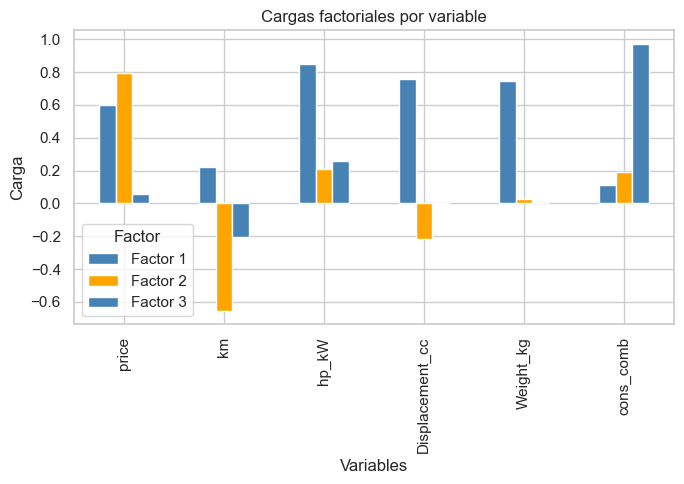

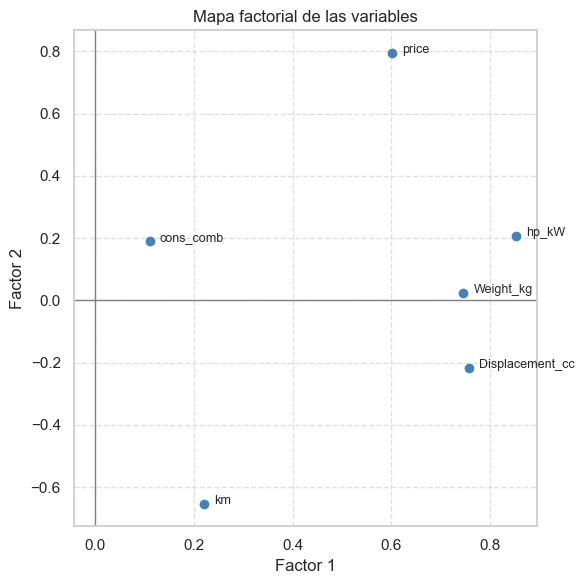

In [50]:
# ============================================
# ANÁLISIS FACTORIAL - VARIABLES CONTINUAS AUTOS
# ============================================


# --- Selección de variables continuas ---
variables = ['price', 'km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']
df_cont = df[variables].dropna()

# --- Estandarización ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cont)
X_df = pd.DataFrame(X_scaled, columns=variables)

# --- Matriz de correlaciones ---
print("\n📊 MATRIZ DE CORRELACIONES:")
print(X_df.corr().round(3))

# --- Análisis factorial (3 factores) ---
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(X_scaled)

# --- Cargas factoriales ---
cargas = pd.DataFrame(fa.loadings_, index=variables, columns=['Factor 1', 'Factor 2','Factor 3'])
print("\n🔹 CARGAS FACTORIALES:")
print(cargas.round(3))

# --- Varianza explicada ---
var_exp = fa.get_factor_variance()
varianza_df = pd.DataFrame({
    'Varianza': var_exp[0],
    'Proporción': var_exp[1],
    'Acumulada': var_exp[2]
}, index=[f'Factor {i+1}' for i in range(len(var_exp[0]))])
print("\n📈 VARIANZA EXPLICADA:")
print(varianza_df.round(3))

# --- Visualización de las cargas factoriales ---
plt.figure(figsize=(7, 5))
cargas.plot(kind='bar', figsize=(7, 5), color=['steelblue', 'orange'])
plt.title('Cargas factoriales por variable')
plt.xlabel('Variables')
plt.ylabel('Carga')
plt.legend(title='Factor')
plt.tight_layout()
plt.show()

# --- Gráfico de dispersión de variables en el plano factorial ---
plt.figure(figsize=(6,6))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
for i, var in enumerate(variables):
    plt.scatter(cargas.iloc[i,0], cargas.iloc[i,1], color='steelblue')
    plt.text(cargas.iloc[i,0]+0.02, cargas.iloc[i,1], var, fontsize=9)
plt.title('Mapa factorial de las variables')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
df['Fuel'] = df['Fuel'].astype('category').cat.codes

### Detección y análisis de atípicos 

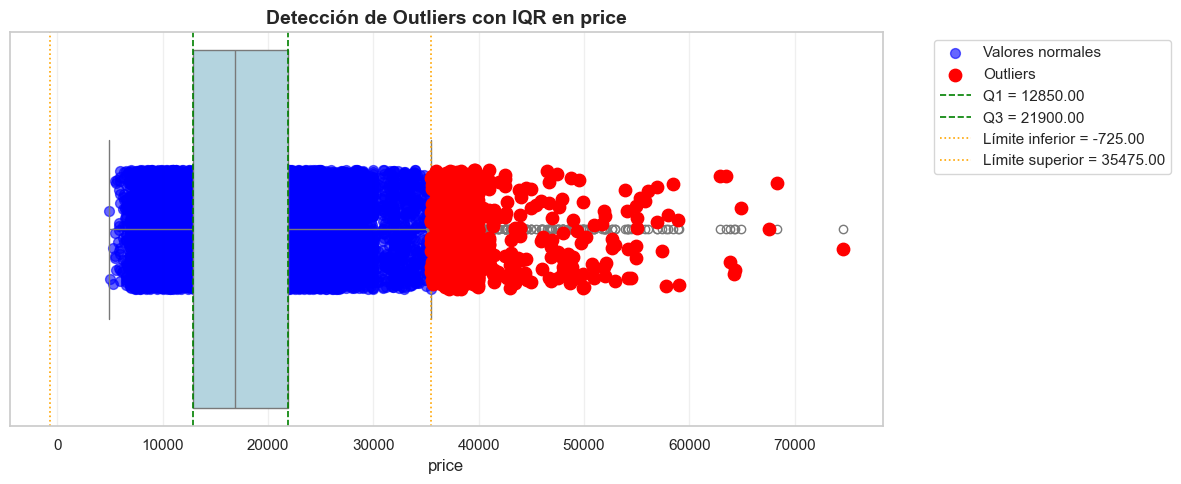

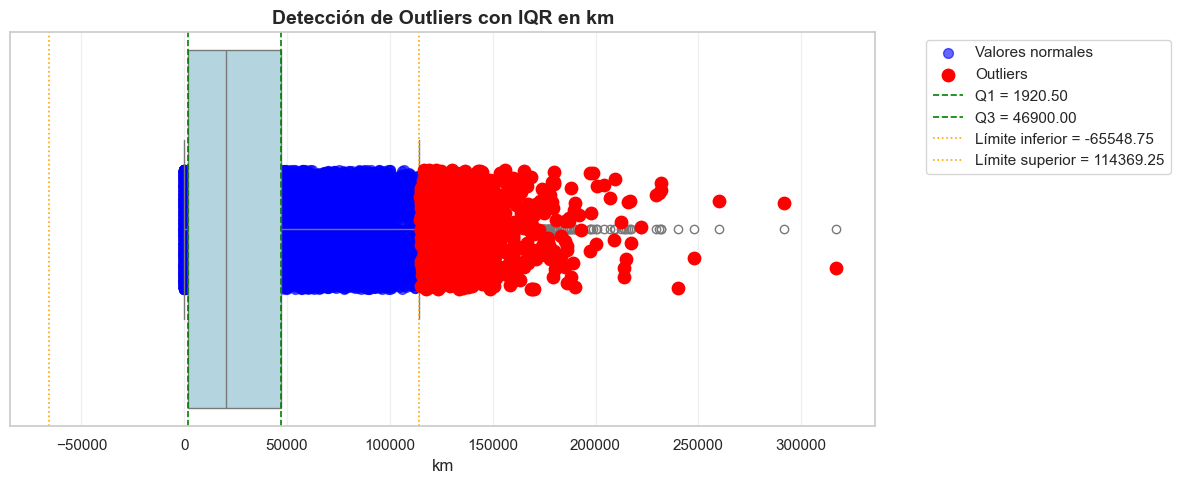

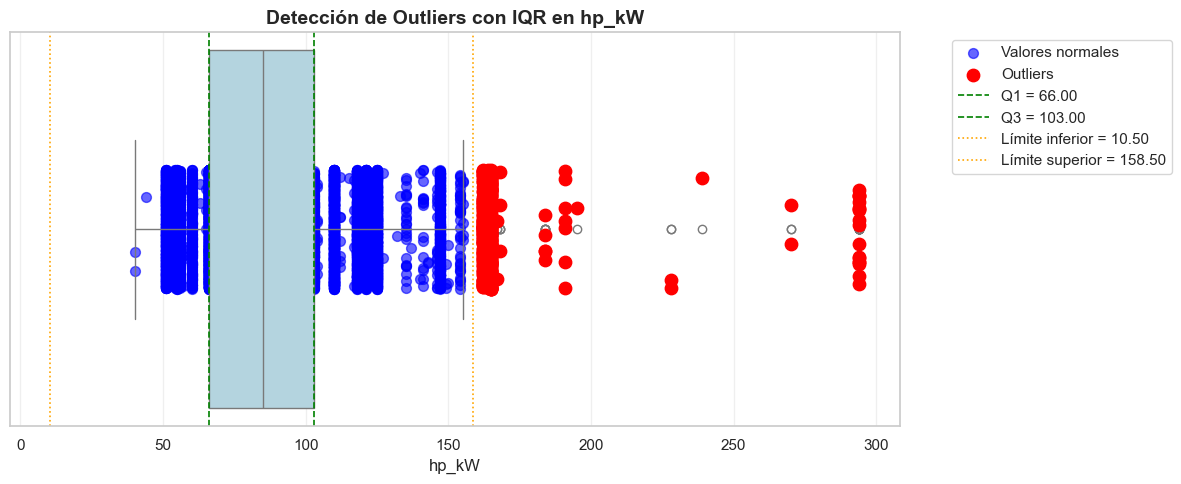

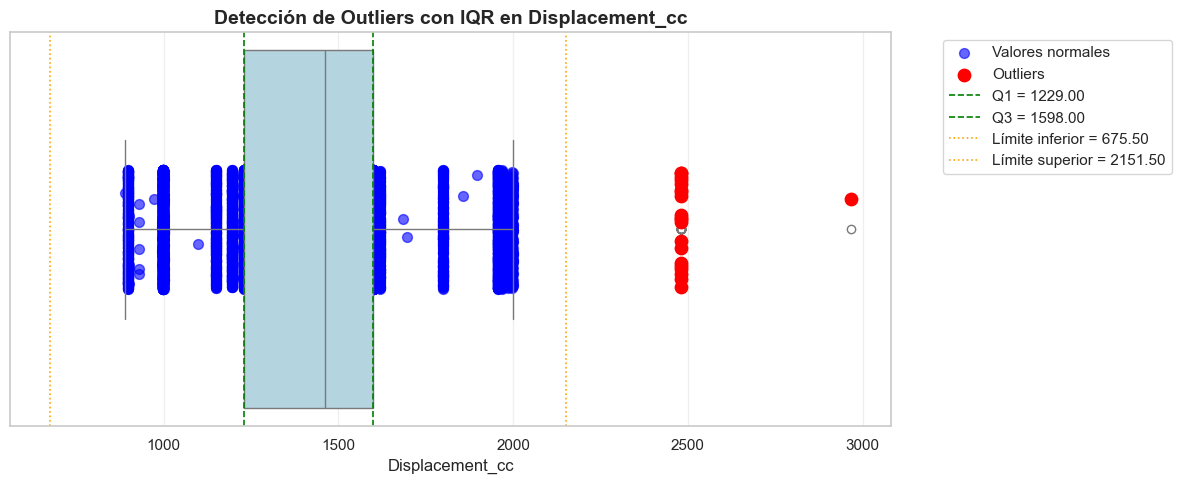

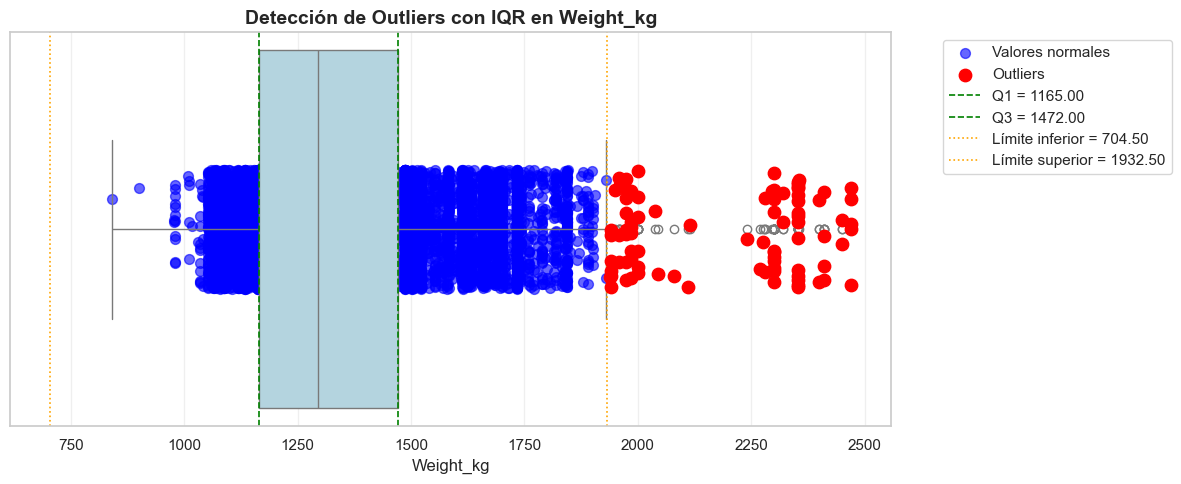

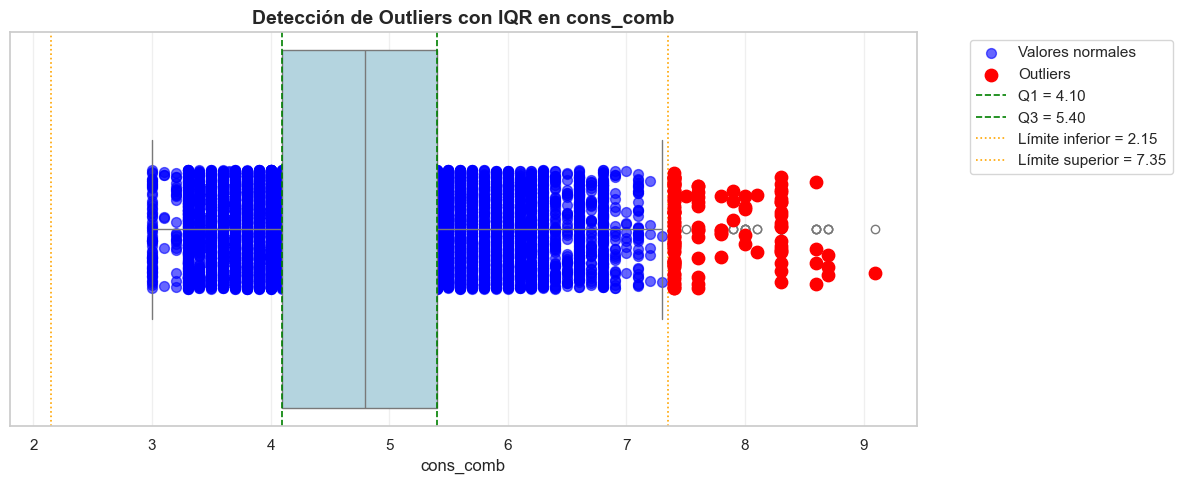

In [46]:

variables_continuas = ['price', 'km','hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb' ]
# Recorremos cada variable continua
for var in variables_continuas:
    if var in df.columns:
        data = df[var].dropna()

        # Cálculo de IQR
        Q1, Q3 = np.percentile(data, [25, 75])
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Identificar outliers y valores normales
        outliers_iqr = data[(data < limite_inferior) | (data > limite_superior)]
        normales_iqr = data[(data >= limite_inferior) & (data <= limite_superior)]

        # Gráfico
        plt.figure(figsize=(12, 5))
        sns.boxplot(x=data, color="lightblue", width=0.3)

        plt.scatter(normales_iqr, np.random.uniform(-0.05, 0.05, size=len(normales_iqr)),
                    color="blue", s=50, alpha=0.6, label="Valores normales")
        plt.scatter(outliers_iqr, np.random.uniform(-0.05, 0.05, size=len(outliers_iqr)),
                    color="red", s=80, zorder=5, label="Outliers")

        plt.axvline(Q1, color="green", linestyle="--", linewidth=1.2, label=f"Q1 = {Q1:.2f}")
        plt.axvline(Q3, color="green", linestyle="--", linewidth=1.2, label=f"Q3 = {Q3:.2f}")
        plt.axvline(limite_inferior, color="orange", linestyle=":", linewidth=1.2, label=f"Límite inferior = {limite_inferior:.2f}")
        plt.axvline(limite_superior, color="orange", linestyle=":", linewidth=1.2, label=f"Límite superior = {limite_superior:.2f}")

        plt.title(f"Detección de Outliers con IQR en {var}", fontsize=14, weight="bold")
        plt.xlabel(var)
        plt.yticks([])  # quitar eje Y porque no aporta
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.grid(alpha=0.3, axis="x")
        plt.tight_layout()
        plt.show()


C:\Users\Nitro V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


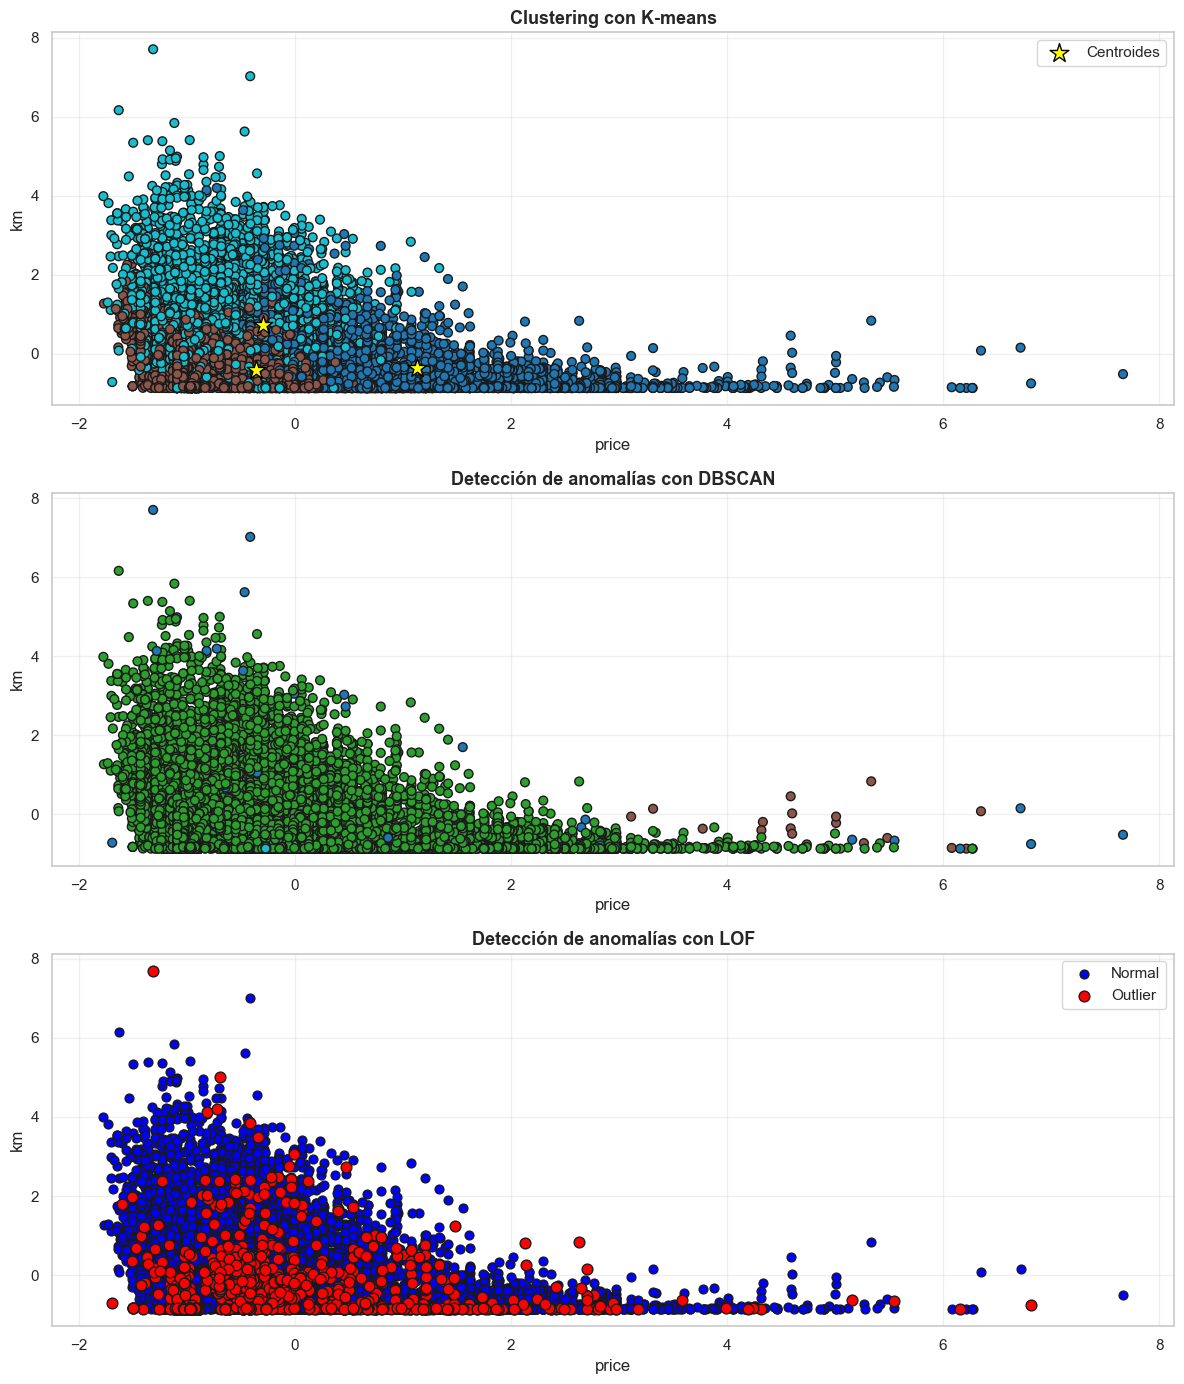

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# Variables continuas del dataset
variables_continuas = ['price', 'km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']

# Selección y estandarización
X = df[variables_continuas].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---- K-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# ---- DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=6)
labels_dbscan = dbscan.fit_predict(X_scaled)

# ---- LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels_lof = lof.fit_predict(X_scaled)

# ---- Visualización: mostramos en 2D usando las dos primeras variables
plt.figure(figsize=(12, 14))

# 1️⃣ K-means
plt.subplot(3, 1, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans, cmap="tab10", s=40, edgecolor="k")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="yellow", s=200, edgecolor="black", marker="*", label="Centroides")
plt.title("Clustering con K-means", fontsize=13, weight="bold")
plt.xlabel(variables_continuas[0]); plt.ylabel(variables_continuas[1])
plt.legend(); plt.grid(alpha=0.3)

# 2️⃣ DBSCAN
plt.subplot(3, 1, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_dbscan, cmap="tab10", s=40, edgecolor="k")
plt.title("Detección de anomalías con DBSCAN", fontsize=13, weight="bold")
plt.xlabel(variables_continuas[0]); plt.ylabel(variables_continuas[1])
plt.grid(alpha=0.3)

# 3️⃣ LOF
plt.subplot(3, 1, 3)
plt.scatter(X_scaled[labels_lof == 1, 0], X_scaled[labels_lof == 1, 1],
            c="blue", s=40, label="Normal", edgecolor="k")
plt.scatter(X_scaled[labels_lof == -1, 0], X_scaled[labels_lof == -1, 1],
            c="red", s=60, label="Outlier", edgecolor="k")
plt.title("Detección de anomalías con LOF", fontsize=13, weight="bold")
plt.xlabel(variables_continuas[0]); plt.ylabel(variables_continuas[1])
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
